# Statistics for Michel electron candidate

### Created by Shu, 20250210---

<br />
<br />

##  Decay point distribution drawing; for MC 2K Files

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D



# Specify the file name
#read data---
decayX = []
decayY = []
decayZ = []
michelScore = []
michelHits = []


with open('./statResult/decayX.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayX.append(float(currentPlace))
with open('./statResult/decayY.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayY.append(float(currentPlace))
with open('./statResult/decayZ.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayZ.append(float(currentPlace))
        
with open('./statResult/michelScore.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        michelScore.append(float(currentPlace))
with open('./statResult/michelHits.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        michelHits.append(float(currentPlace))        




print("Length of decayX: ", len(decayX))
print("Length of decayY: ", len(decayY))
print("Length of decayZ: ", len(decayZ))
print("Length of michelScore: ", len(michelScore))
print("Length of michelHits: ", len(michelHits))


Length of decayX:  18438
Length of decayY:  18438
Length of decayZ:  18438
Length of michelScore:  18438
Length of michelHits:  18438


<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />


## Initial drawing, NO cuts

Distance to APAs    [0, 10]:  211
Distance to APAs   (10, 50]:  253
Distance to APAs  (50, 100]:  556
Distance to APAs (100, 200]:  2433
Distance to APAs (200, 300]:  7098
Distance to APAs (300, inf):  7887


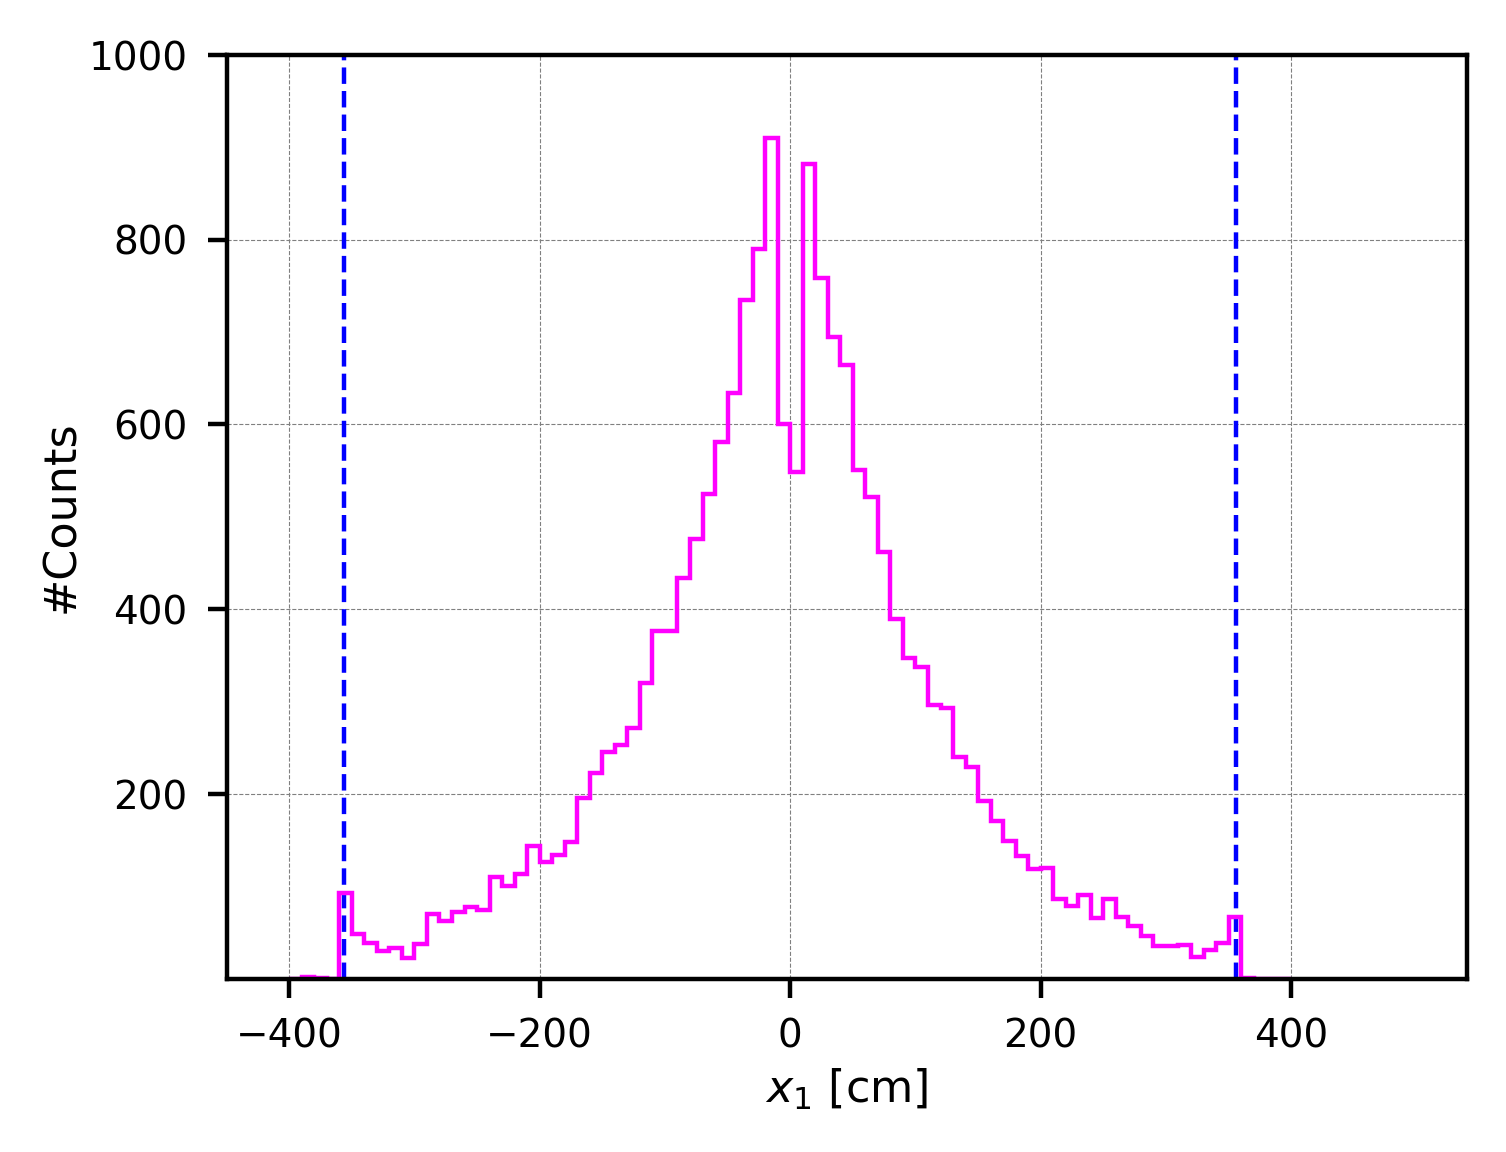

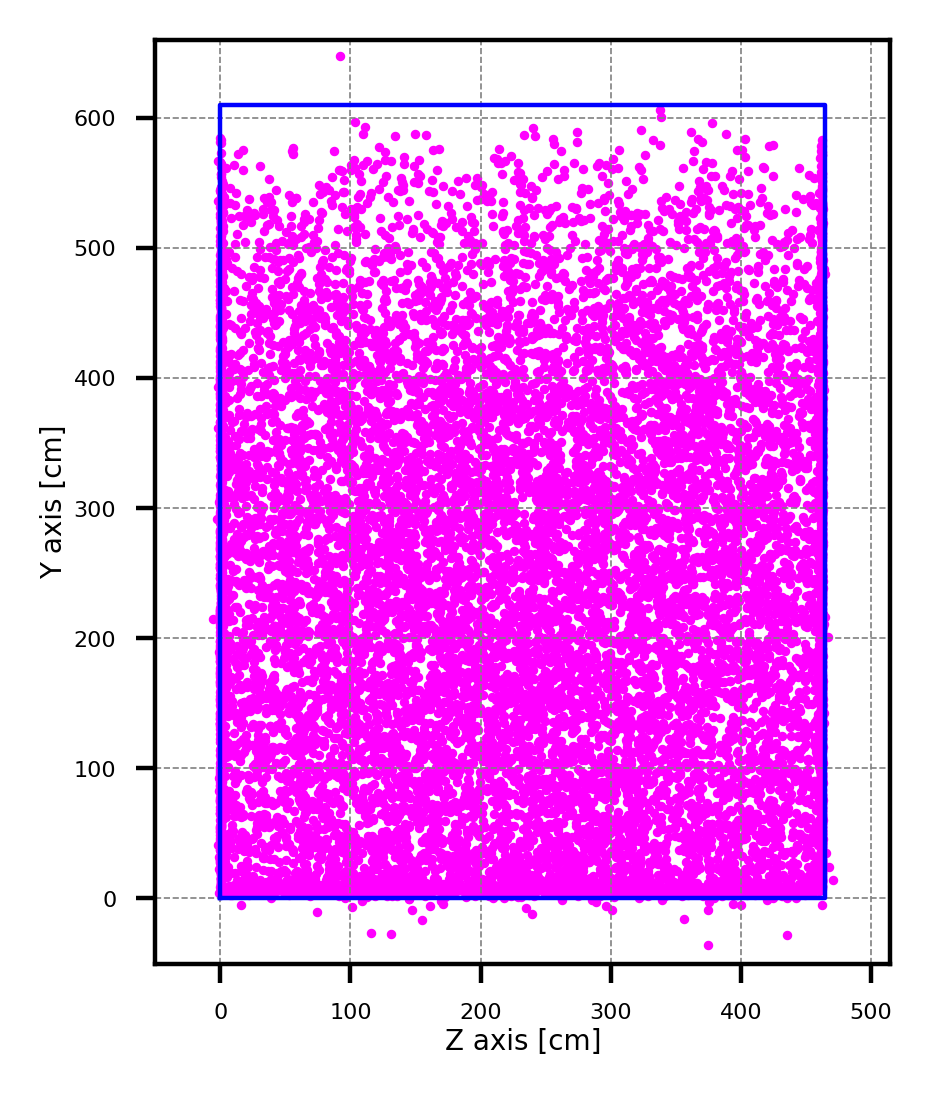

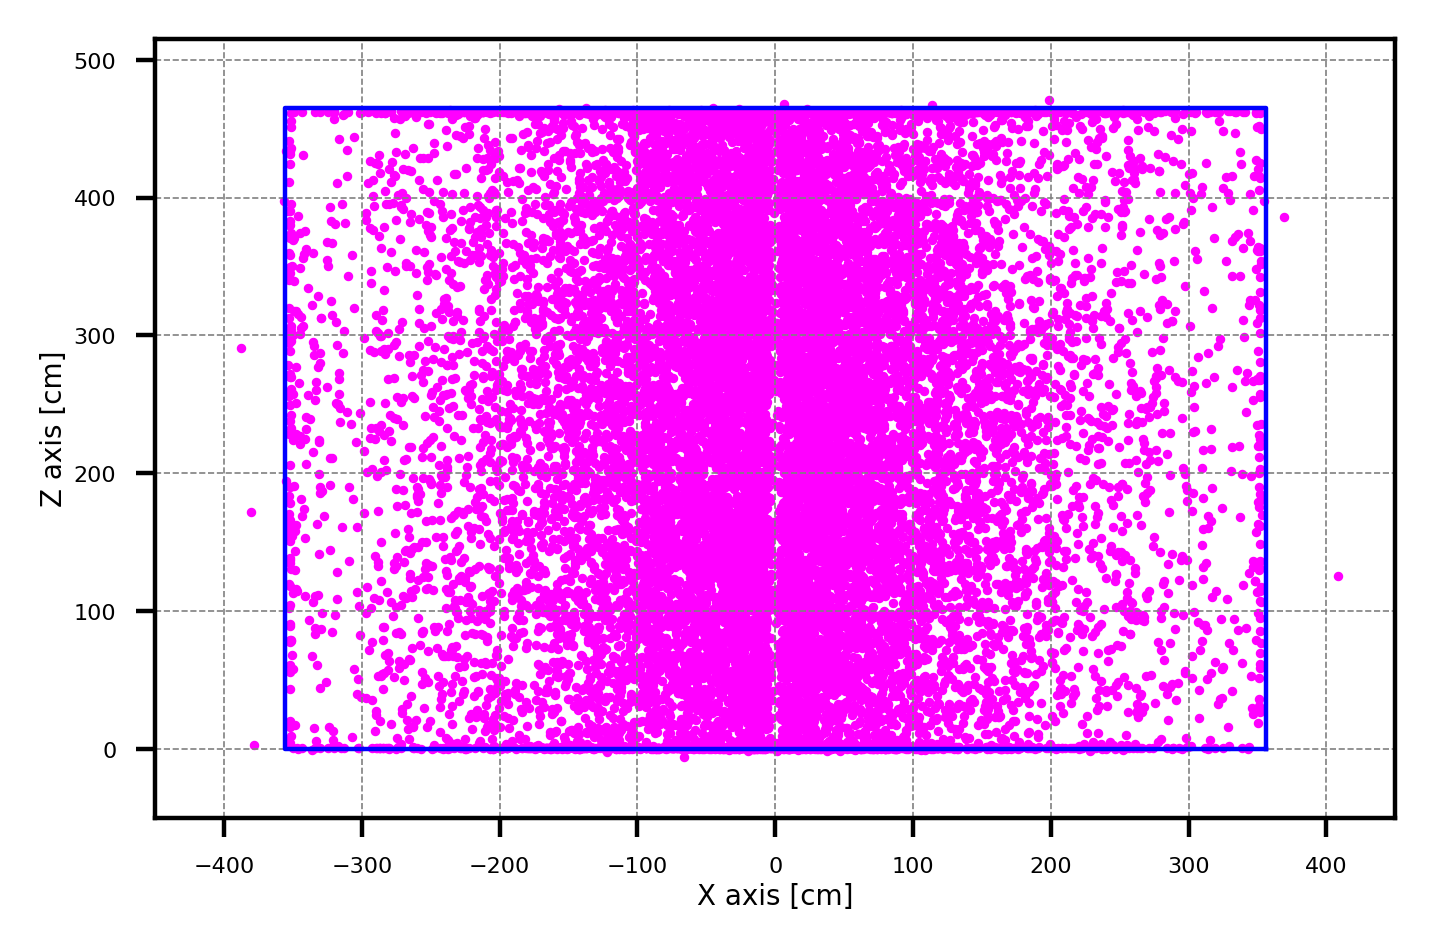

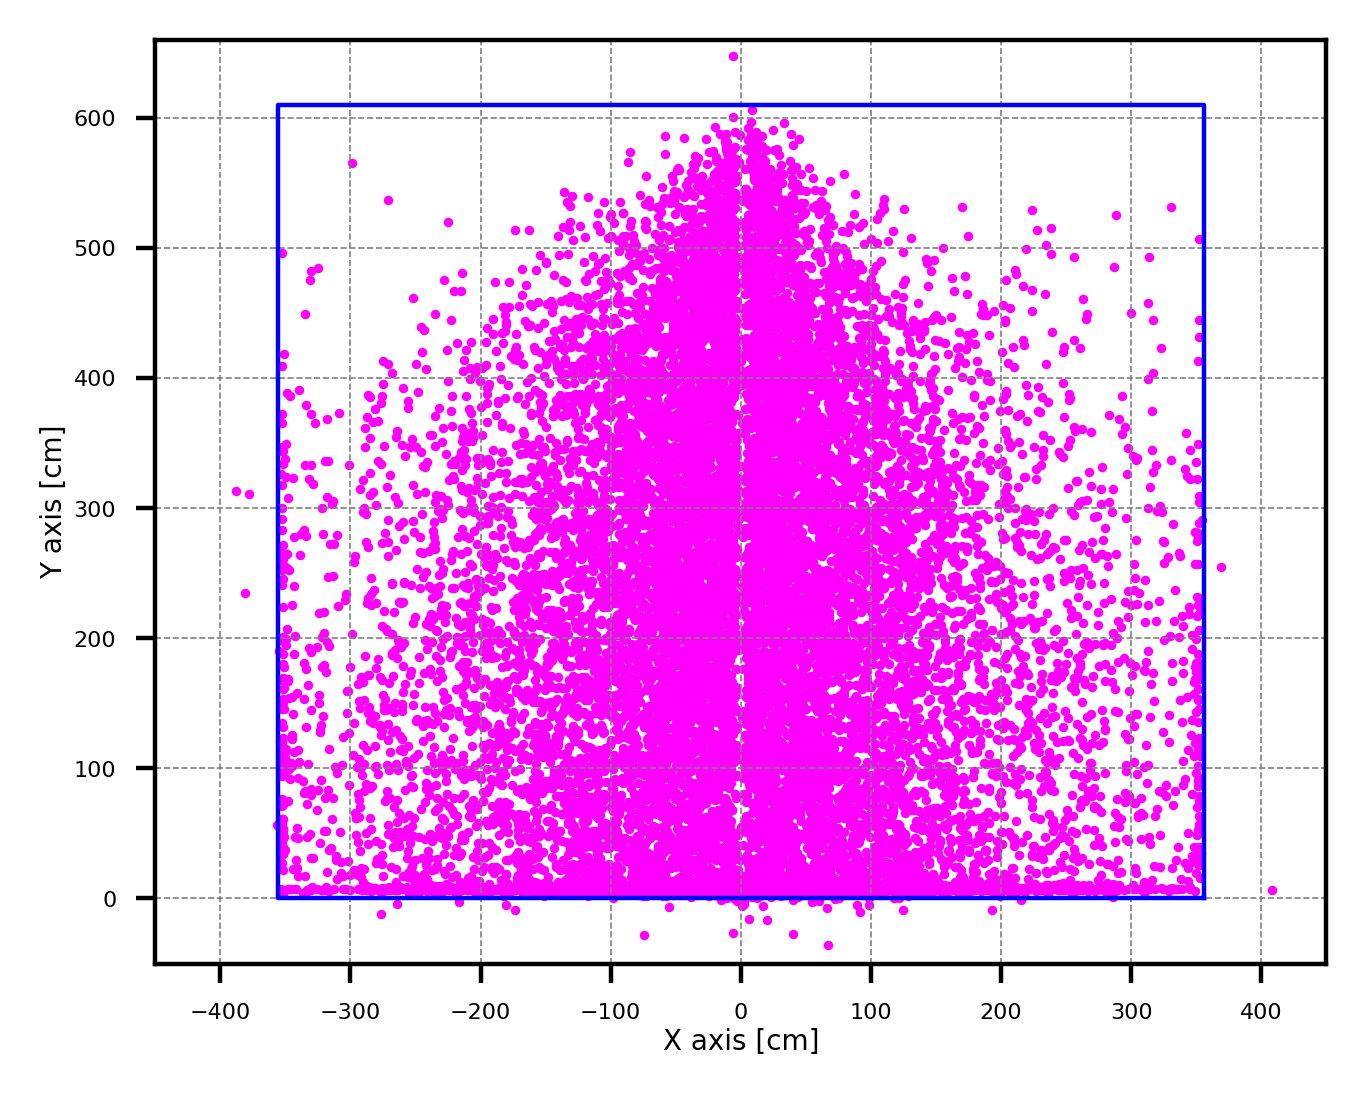

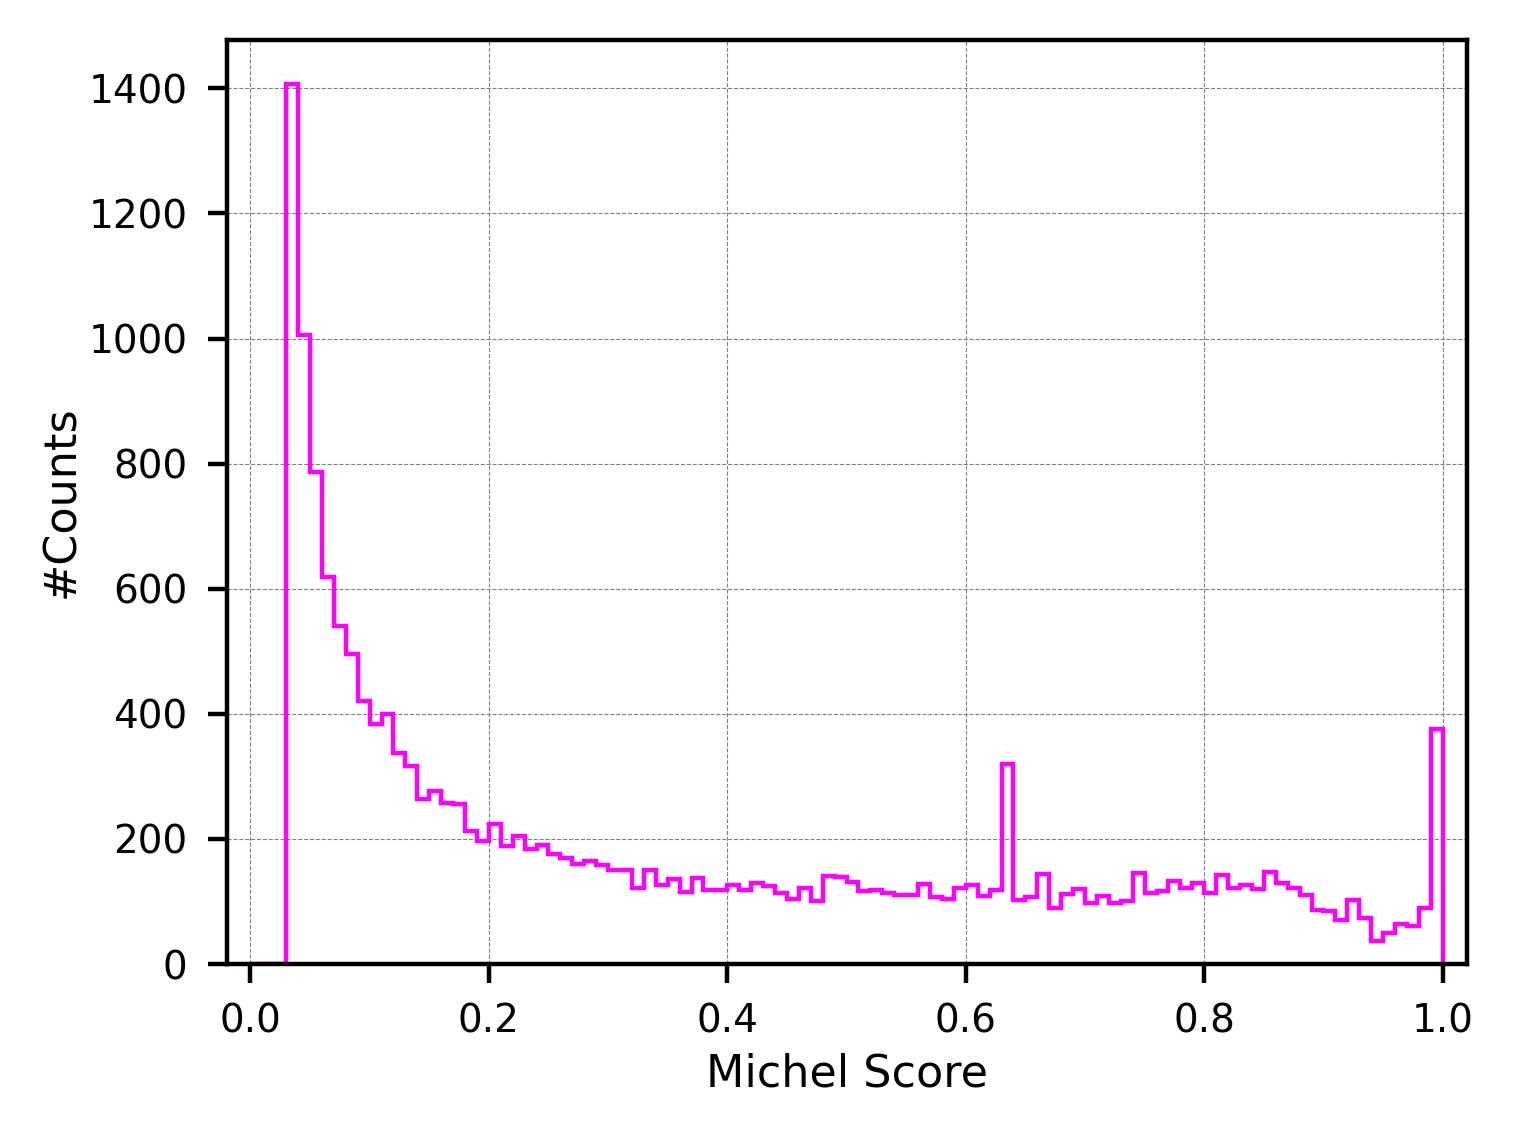

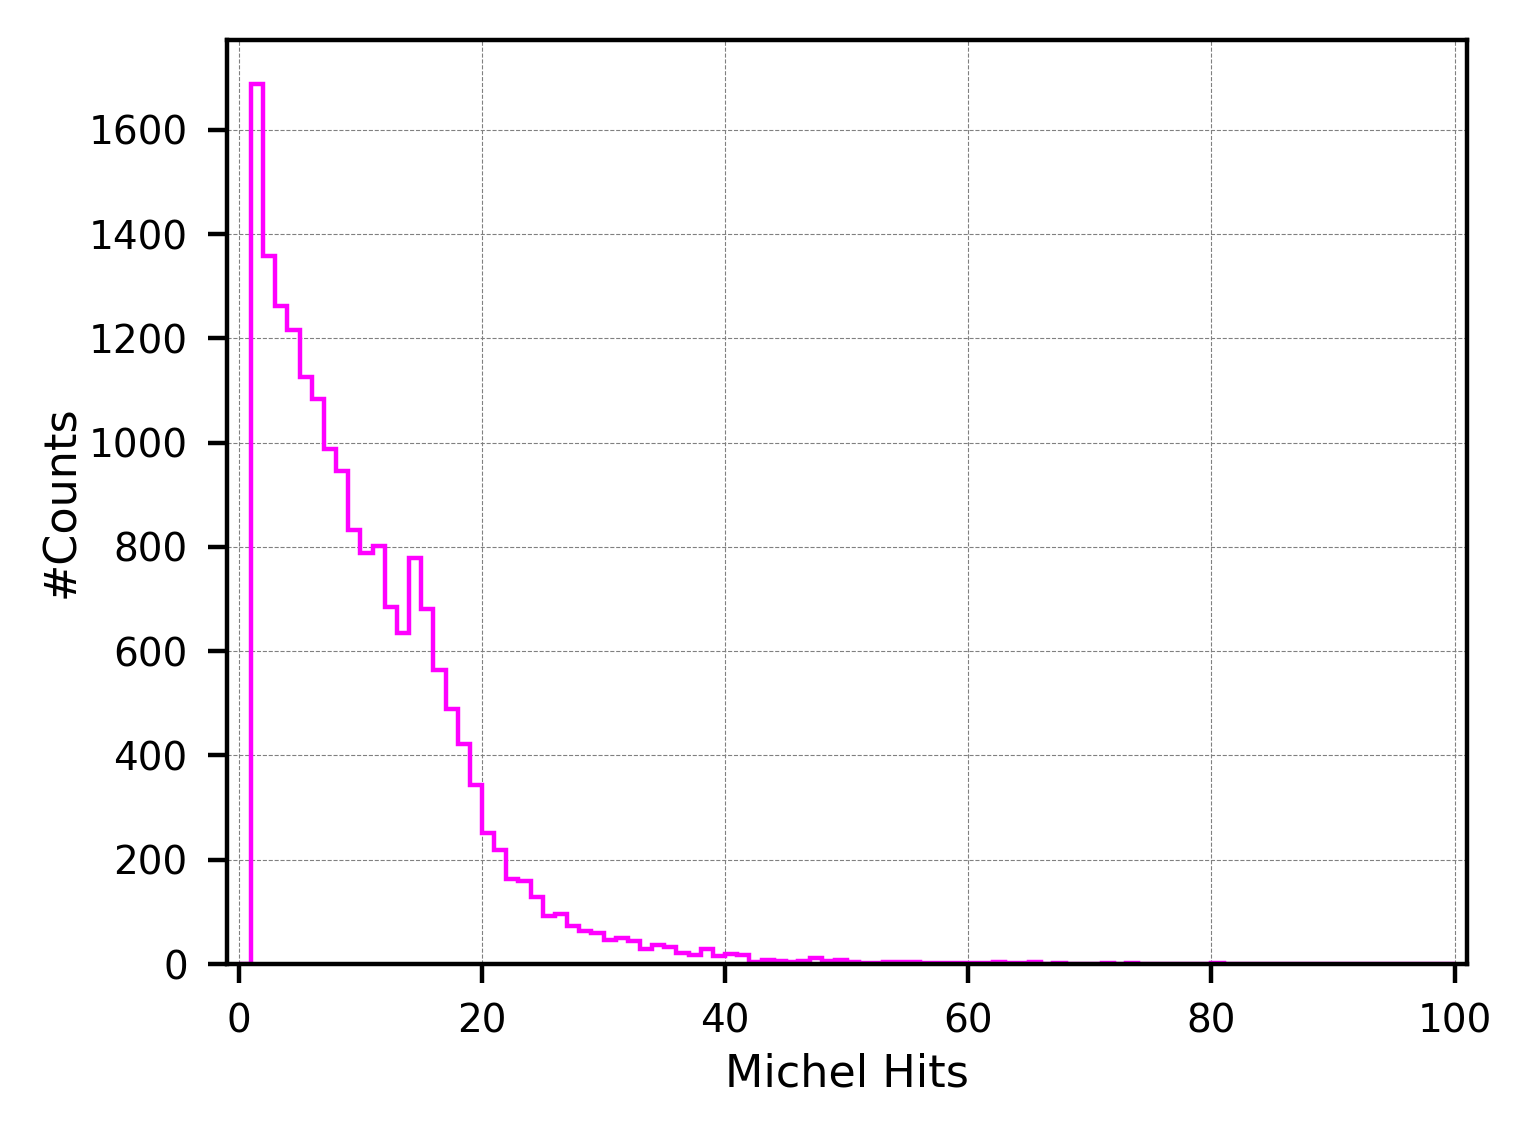

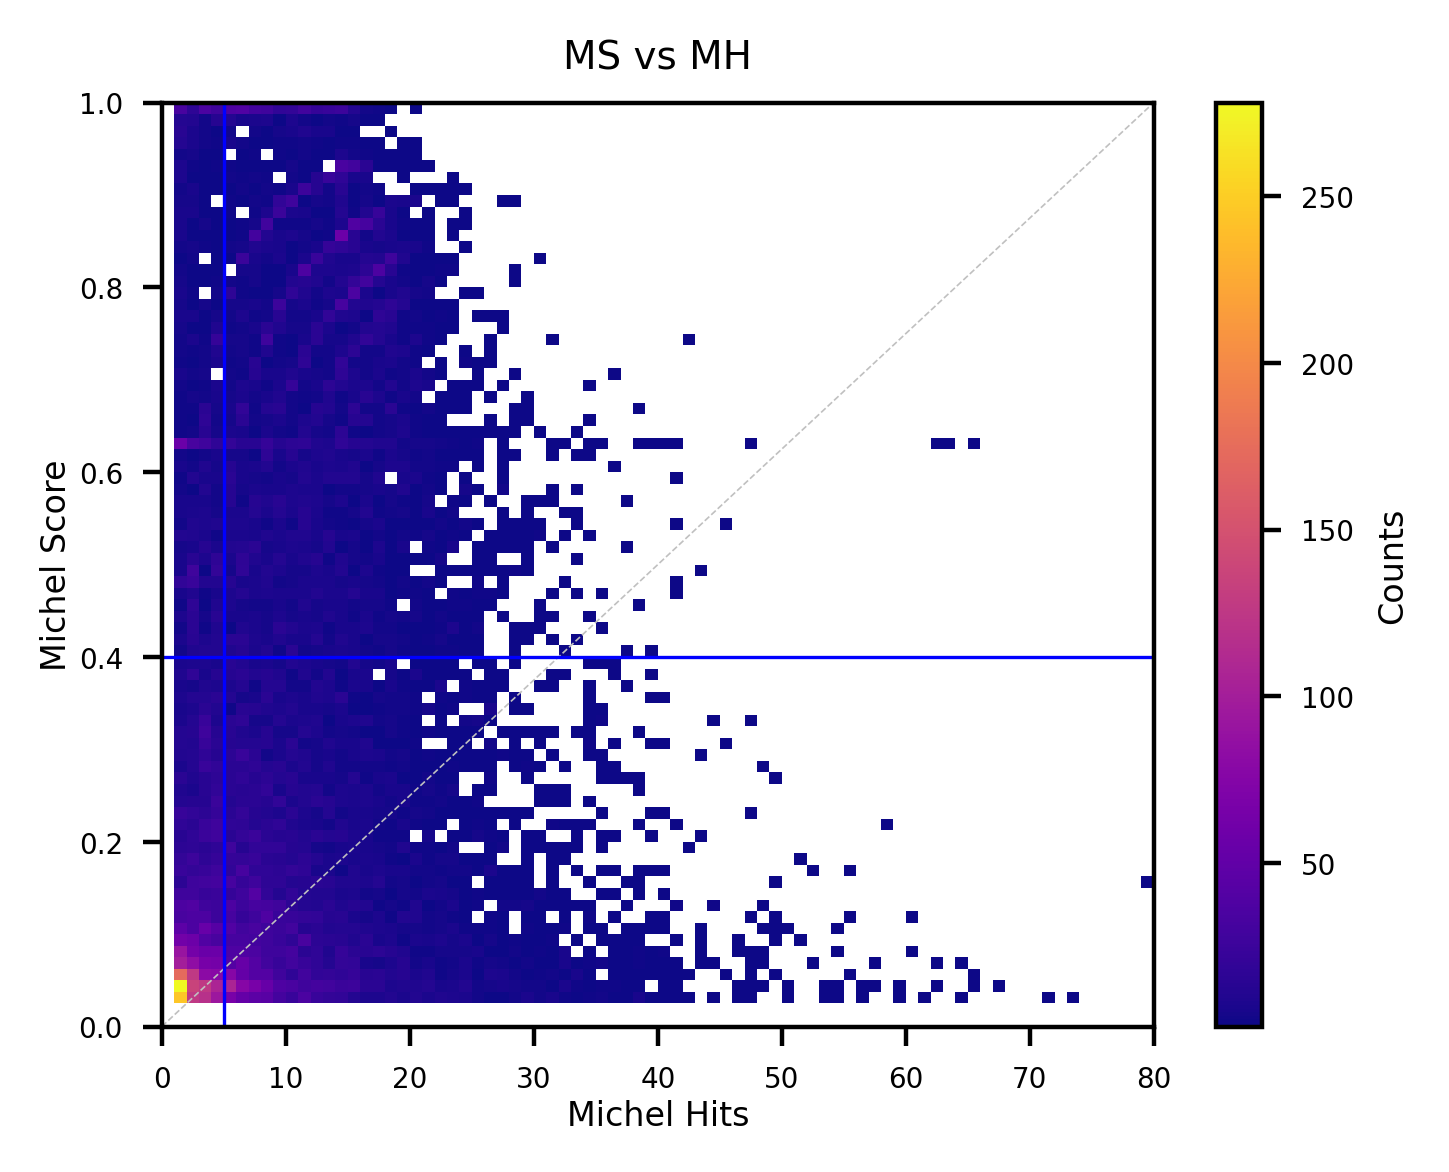

In [2]:
#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465





#Statistics for different distances-----------------------
count10 = 0
count10_50 = 0
count50_100 = 0
count100_200 = 0
count200_300 = 0
count300 = 0

for value in decayX:
    #APA planes are at x=-356 & x=356
    if  value <= -346 or value >= 346:
        count10 += 1
    elif -346 < value <= -306 or 306 <= value < 346:
        count10_50 += 1
    elif -306 < value <= -256 or 256 <= value < 306:
        count50_100 += 1 
    elif -256 < value <= -156 or 156 <= value < 256:
        count100_200 += 1    
    elif -156 < value <= -56 or 56 <= value < 156:
        count200_300 += 1 
    else:
        count300 += 1

# Output the counts
print("Distance to APAs    [0, 10]: ", count10)
print("Distance to APAs   (10, 50]: ", count10_50)
print("Distance to APAs  (50, 100]: ", count50_100)
print("Distance to APAs (100, 200]: ", count100_200)
print("Distance to APAs (200, 300]: ", count200_300)
print("Distance to APAs (300, inf): ", count300)

  




# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-356, -356], [0, 1000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 1000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(decayX, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(-450, 540)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  







#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(decayZ, decayY, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()  







#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(decayX, decayZ, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 515)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 






#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(decayX, decayY, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 







#Michel score distribution (Original)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 0.01
range_min = 0
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(michelScore, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(-0.02, 1.02)
plt.xlabel('Michel Score', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 800)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  







#Michel hits distribution (Original)-----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(michelHits, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(-1, 101)
plt.xlabel('Michel Hits', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 800)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  






#Michel Score vs Michel Hits==========================================================
plt.figure(figsize=(4,3),dpi=400)

#y=x---
plt.plot([0, 80], [0, 1], color="silver", linewidth=0.3, linestyle='--')
plt.plot([0, 80], [0.4, 0.4], color="blue", linewidth=0.6, linestyle='-')
plt.plot([5, 5], [0, 1], color="blue", linewidth=0.6, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(michelHits, michelScore, bins=(80, 80), range=[[0, 80], [0, 1]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

# Labels and styling
plt.xlim(0, 80)
plt.ylim(0, 1)
plt.xlabel('Michel Hits', labelpad=1, fontsize=6)
plt.ylabel('Michel Score', labelpad=1, fontsize=6)
plt.title('MS vs MH', fontsize=7)
plt.tick_params(labelsize=5)





<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />


## Apply Cuts Manually:

In [3]:

#Space Cut---
ScutX = []
ScutY = []
ScutZ = []
ScutMS = []
ScutMH = []

#Michel Score cut (after space cut)---
MScutX = []
MScutY = []
MScutZ = []
MScutMS = []
MScutMH = []

#Michel Hits cut (after michel score cut)---
MHcutX = []
MHcutY = []
MHcutZ = []
MHcutMS = []
MHcutMH = []


for i in range(0, len(decayX)):
    X = decayX[i]
    Y = decayY[i]
    Z = decayZ[i]
    MS = michelScore[i]
    MH = michelHits[i]
  
    #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
    if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:
        ScutX.append(X)
        ScutY.append(Y)
        ScutZ.append(Z)
        ScutMS.append(MS)
        ScutMH.append(MH)      

        if 0.4 < MS: #(Michel score cut)---
            MScutX.append(X)
            MScutY.append(Y)
            MScutZ.append(Z)
            MScutMS.append(MS)
            MScutMH.append(MH)  
            
            if 5 < MH: #Michel hits cut---
                MHcutX.append(X)
                MHcutY.append(Y)
                MHcutZ.append(Z)
                MHcutMS.append(MS)
                MHcutMH.append(MH)
            

#Initial size of dataset:-----
print("Size of X (initial) : ", len(decayX))
print("Size of Y (initial) : ", len(decayY))
print("Size of Z (initial) : ", len(decayZ))
print("Size of MS (initial): ", len(michelScore))
print("Size of MH (initial): ", len(michelHits))

print("\nSize of X (space cut) : ", len(ScutX), "({:.3f}%)".format(len(ScutX)/len(decayX)*100))
print("Size of Y (space cut) : ", len(ScutY))
print("Size of Z (space cut) : ", len(ScutZ))
print("Size of MS (space cut): ", len(ScutMS))
print("Size of MH (space cut): ", len(ScutMH))

print("\nSize of X (space cut & MS cut) : ", len(MScutX), "({:.3f}%)".format(len(MScutX)/len(decayX)*100))
print("Size of Y (space cut & MS cut) : ", len(MScutY))
print("Size of Z (space cut & MS cut) : ", len(MScutZ))
print("Size of MS (space cut & MS cut): ", len(MScutMS))
print("Size of MH (space cut & MS cut): ", len(MScutMH))


print("\nSize of X (space cut & MS cut & MH cut) : ", len(MHcutX), "({:.3f}%)".format(len(MHcutX)/len(decayX)*100))
print("Size of Y (space cut & MS cut & MH cut) : ", len(MHcutY))
print("Size of Z (space cut & MS cut & MH cut) : ", len(MHcutZ))
print("Size of MS (space cut & MS cut & MH cut): ", len(MHcutMS))
print("Size of MH (space cut & MS cut & MH cut): ", len(MHcutMH))





Size of X (initial) :  18438
Size of Y (initial) :  18438
Size of Z (initial) :  18438
Size of MS (initial):  18438
Size of MH (initial):  18438

Size of X (space cut) :  9603 (52.083%)
Size of Y (space cut) :  9603
Size of Z (space cut) :  9603
Size of MS (space cut):  9603
Size of MH (space cut):  9603

Size of X (space cut & MS cut) :  4816 (26.120%)
Size of Y (space cut & MS cut) :  4816
Size of Z (space cut & MS cut) :  4816
Size of MS (space cut & MS cut):  4816
Size of MH (space cut & MS cut):  4816

Size of X (space cut & MS cut & MH cut) :  4086 (22.161%)
Size of Y (space cut & MS cut & MH cut) :  4086
Size of Z (space cut & MS cut & MH cut) :  4086
Size of MS (space cut & MS cut & MH cut):  4086
Size of MH (space cut & MS cut & MH cut):  4086


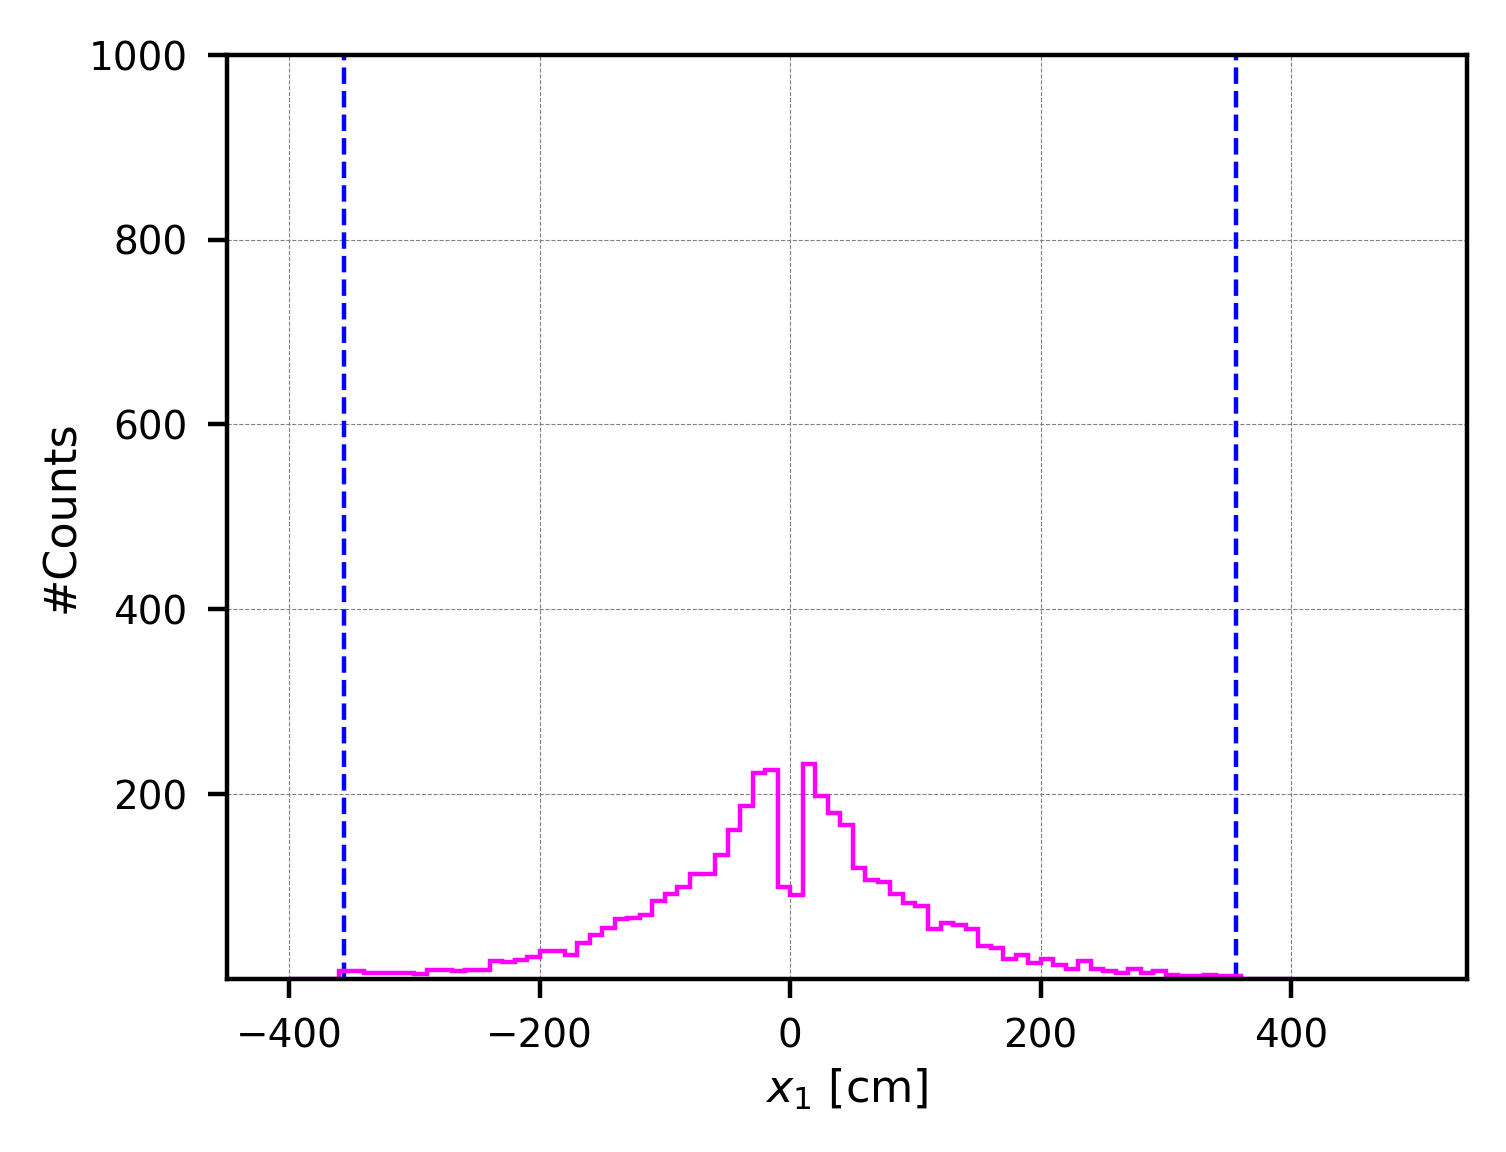

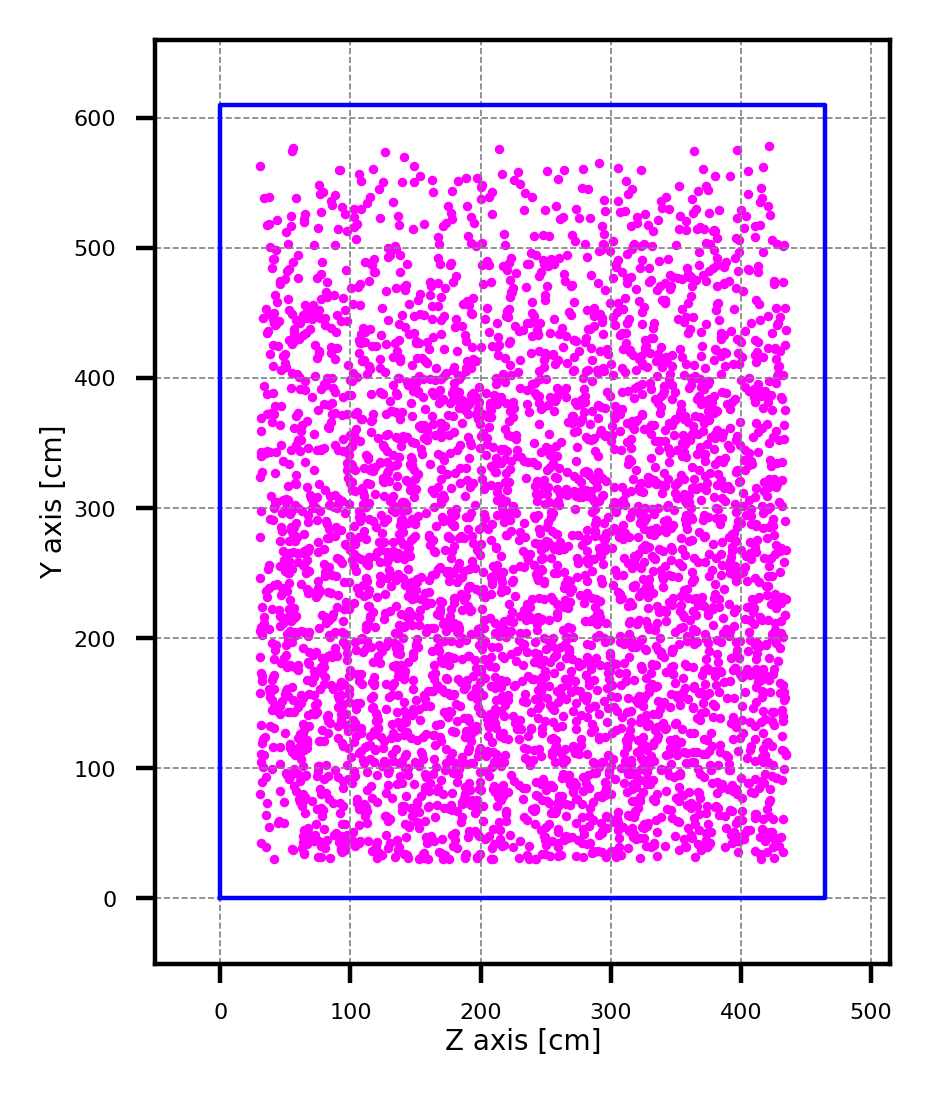

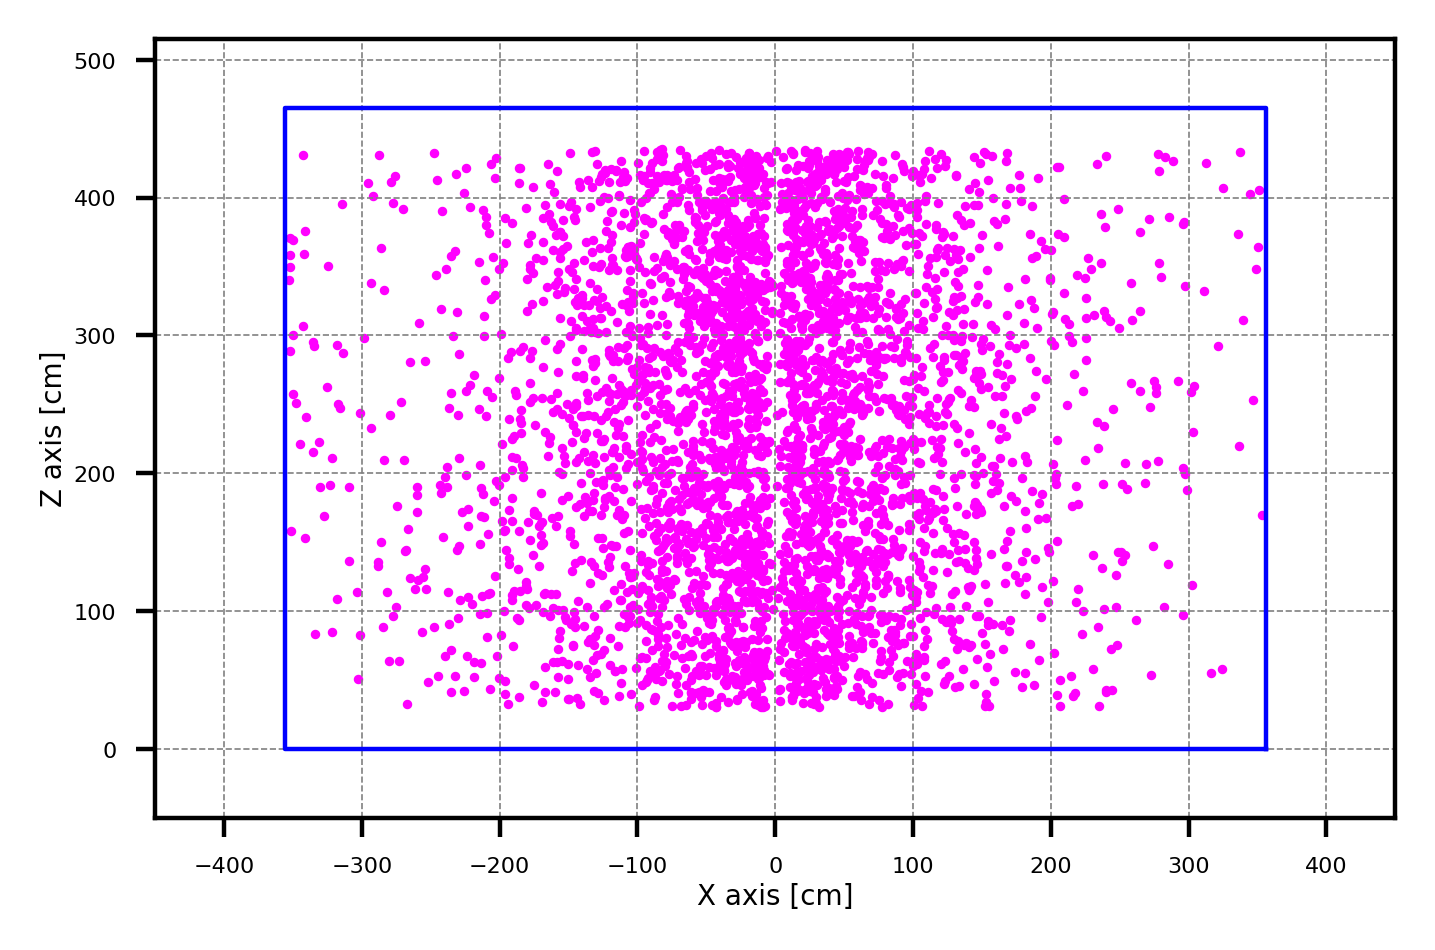

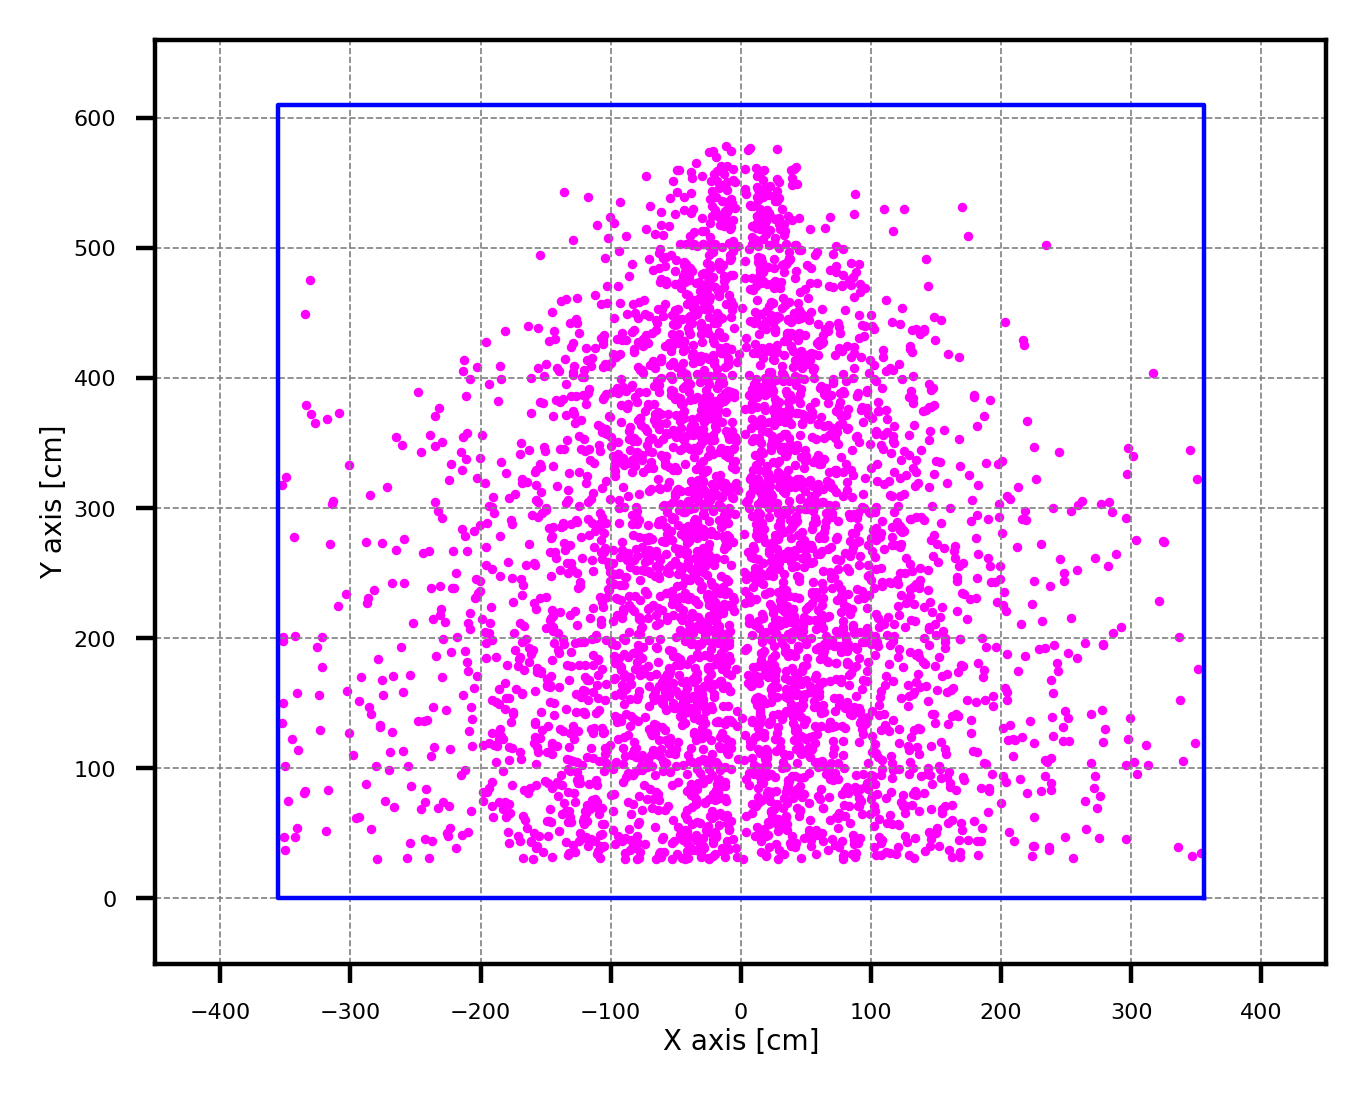

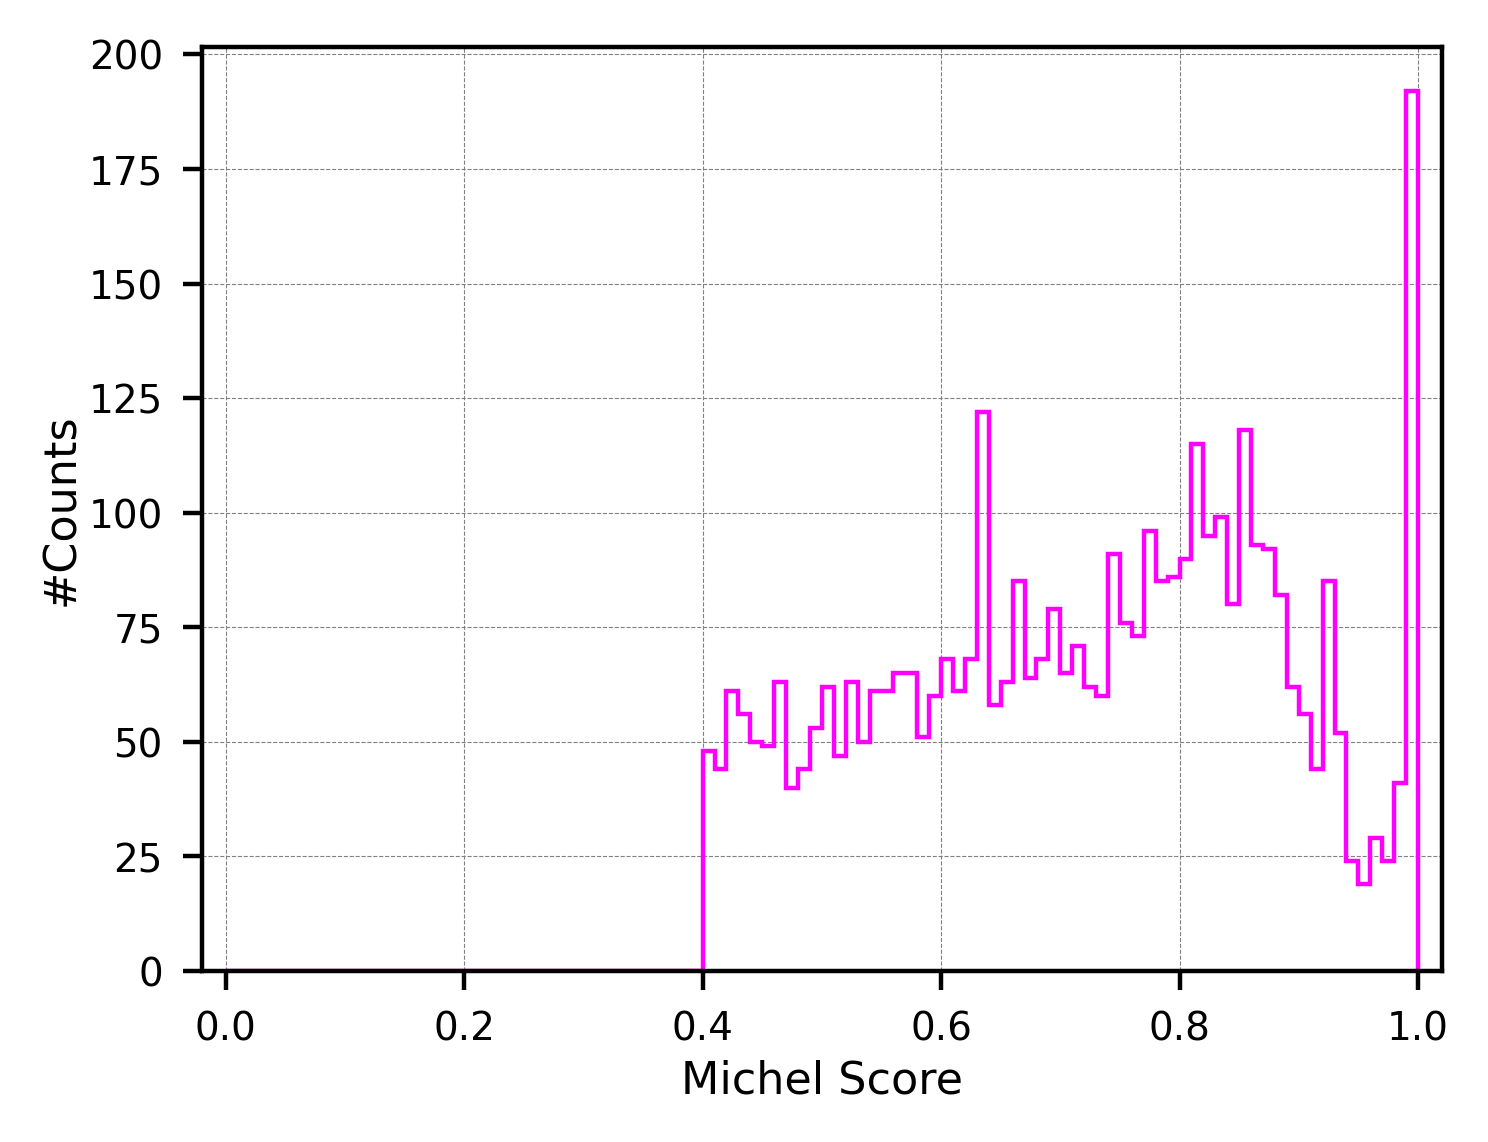

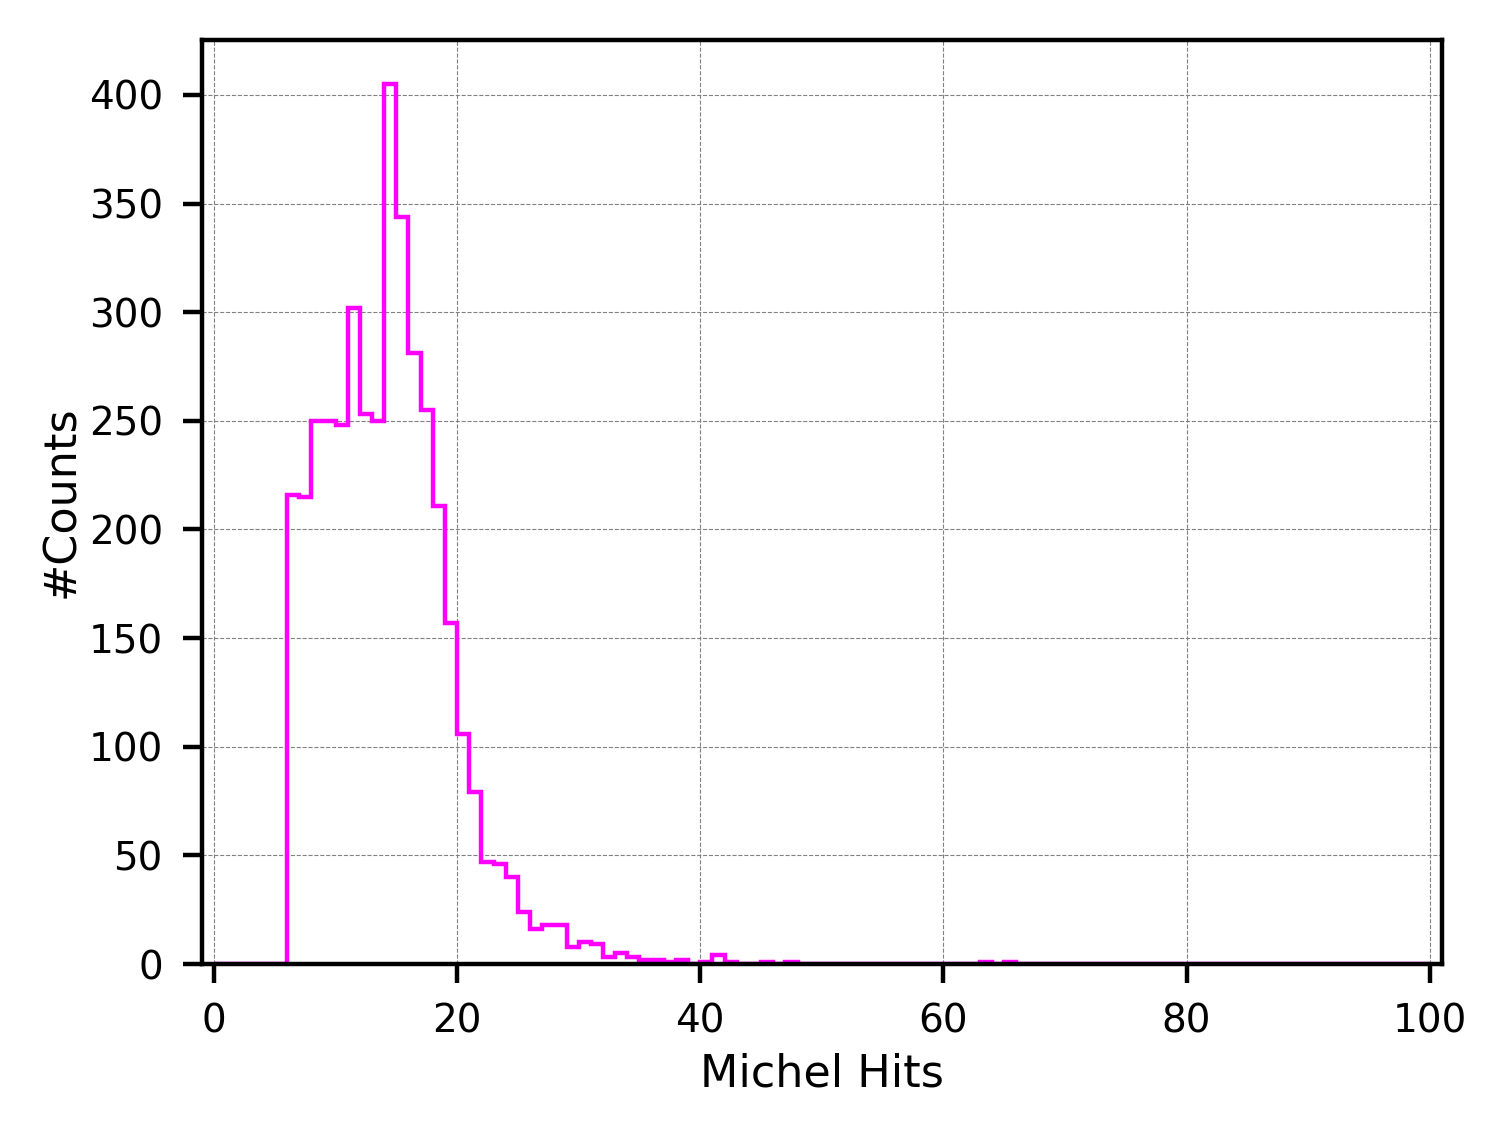


Size of ScutMS:  9603


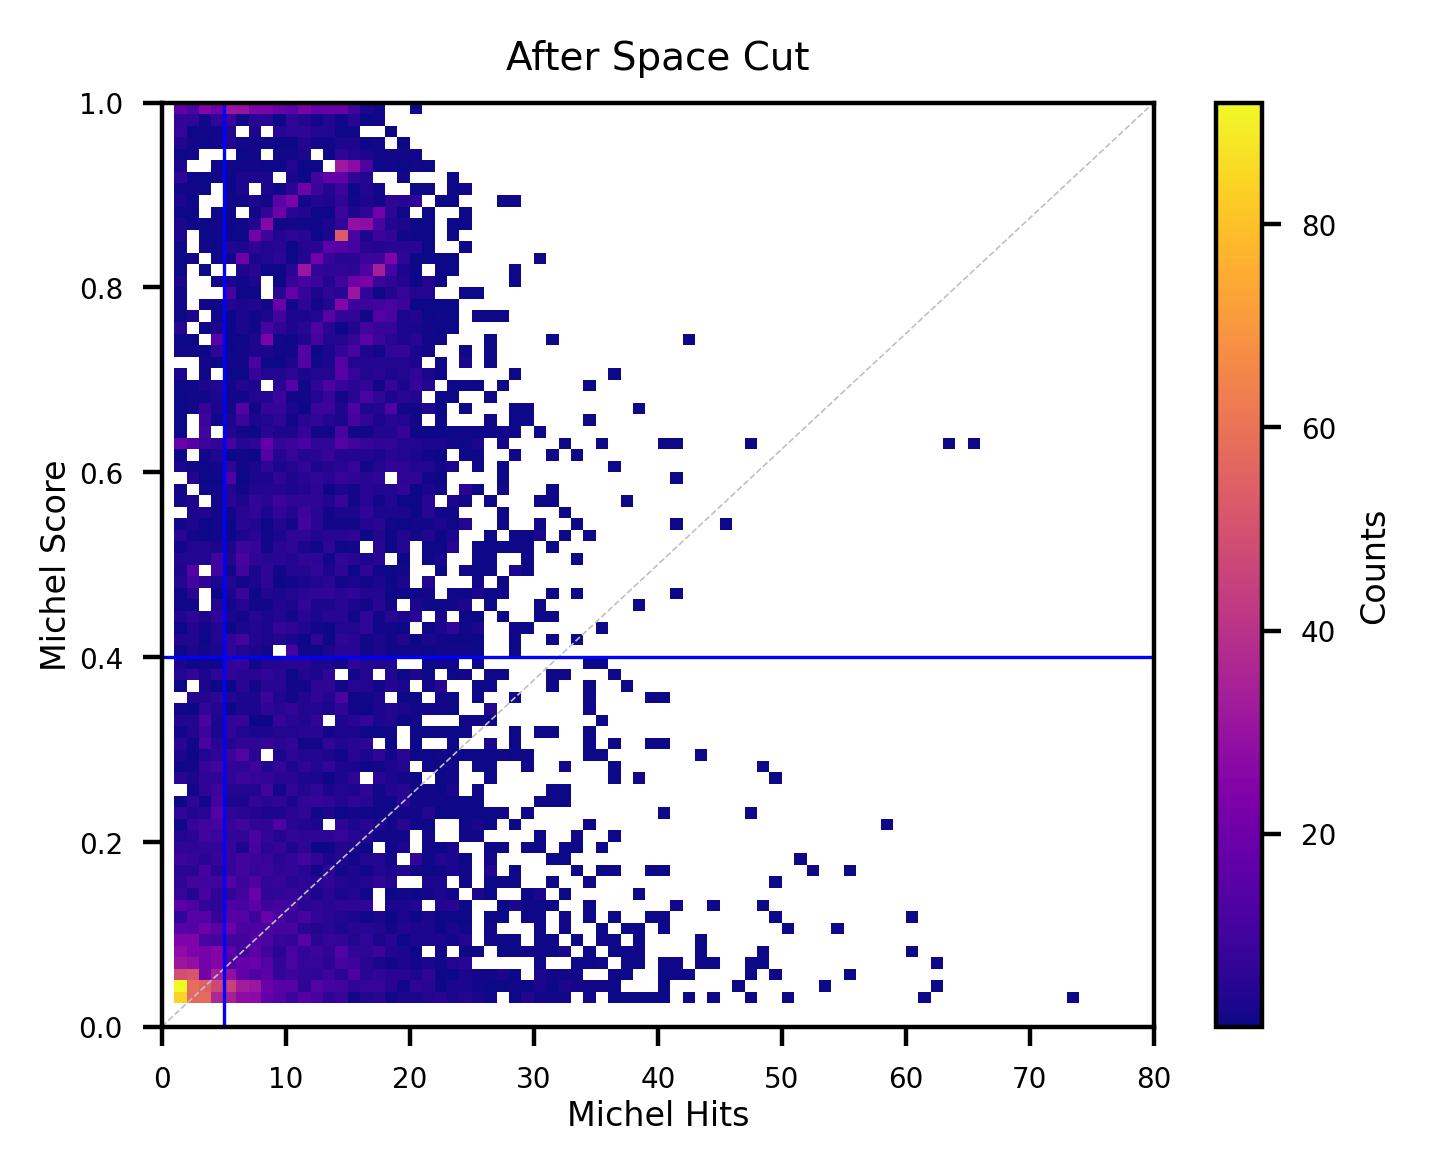

In [4]:
# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-356, -356], [0, 1000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 1000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(MHcutX, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(-450, 540)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  







#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(MHcutZ, MHcutY, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()  







#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(MHcutX, MHcutZ, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 515)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 






#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(MHcutX, MHcutY, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 







#Michel score distribution (Original)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 0.01
range_min = 0
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(MHcutMS, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(-0.02, 1.02)
plt.xlabel('Michel Score', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 800)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  







#Michel hits distribution (Original)-----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(MHcutMH, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(-1, 101)
plt.xlabel('Michel Hits', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 800)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  







#Michel Score vs Michel Hits=====(AFTER SPACE CUT)==========================================

print("\nSize of ScutMS: ", len(ScutMS))

plt.figure(figsize=(4,3),dpi=400)

#y=x---
plt.plot([0, 80], [0, 1], color="silver", linewidth=0.3, linestyle='--')
plt.plot([0, 80], [0.4, 0.4], color="blue", linewidth=0.6, linestyle='-')
plt.plot([5, 5], [0, 1], color="blue", linewidth=0.6, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(ScutMH, ScutMS, bins=(80, 80), range=[[0, 80], [0, 1]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

# Labels and styling
plt.xlim(0, 80)
plt.ylim(0, 1)
plt.xlabel('Michel Hits', labelpad=1, fontsize=6)
plt.ylabel('Michel Score', labelpad=1, fontsize=6)
plt.title('After Space Cut', fontsize=7)
plt.tick_params(labelsize=5)



<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## FILTERED Events:

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D



# Specify the file name
#read data---
decayX_filtered = []
decayY_filtered = []
decayZ_filtered = []
michelScore_filtered = []
michelHits_filtered = []
startX_filtered = []
startY_filtered = []
startZ_filtered = []

eventID = []
trackID = []


with open('./statResult/decayX_filtered.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayX_filtered.append(float(currentPlace))
with open('./statResult/decayY_filtered.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayY_filtered.append(float(currentPlace))
with open('./statResult/decayZ_filtered.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayZ_filtered.append(float(currentPlace))
        
with open('./statResult/michelScore_filtered.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        michelScore_filtered.append(float(currentPlace))
with open('./statResult/michelHits_filtered.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        michelHits_filtered.append(float(currentPlace))        

with open('./statResult/eventID_filtered.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        eventID.append(float(currentPlace))
with open('./statResult/trackID_filtered.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        trackID.append(float(currentPlace))


print("Length of decayX_filtered: ", len(decayX_filtered))
print("Length of decayY_filtered: ", len(decayY_filtered))
print("Length of decayZ_filtered: ", len(decayZ_filtered))
print("Length of michelScore_filtered: ", len(michelScore_filtered))
print("Length of michelHits_filtered: ", len(michelHits_filtered))
print("\nLength of eventID: ", len(eventID))
print("Length of trackID: ", len(trackID))

print("\nLargest Value of eventID: ", max(eventID))
print("Largest Value of trackID: ", max(trackID))

Length of decayX_filtered:  1670
Length of decayY_filtered:  1670
Length of decayZ_filtered:  1670
Length of michelScore_filtered:  1670
Length of michelHits_filtered:  1670

Length of eventID:  1670
Length of trackID:  1670

Largest Value of eventID:  95502.0
Largest Value of trackID:  56.0


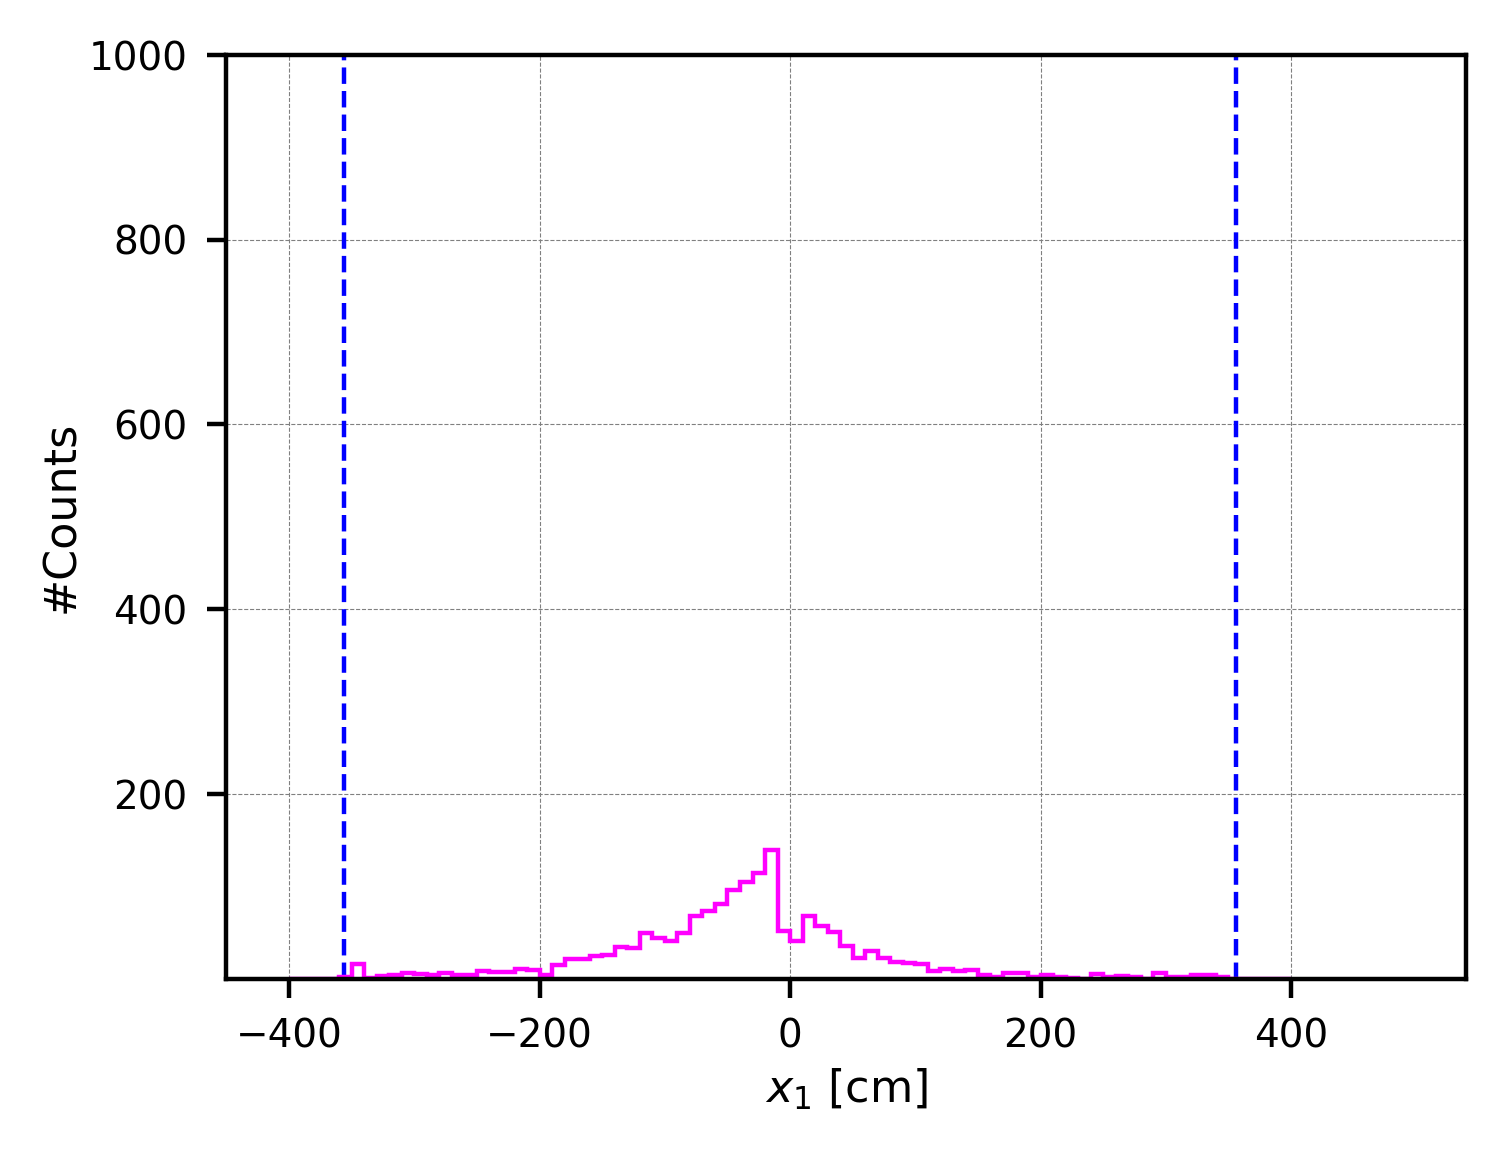

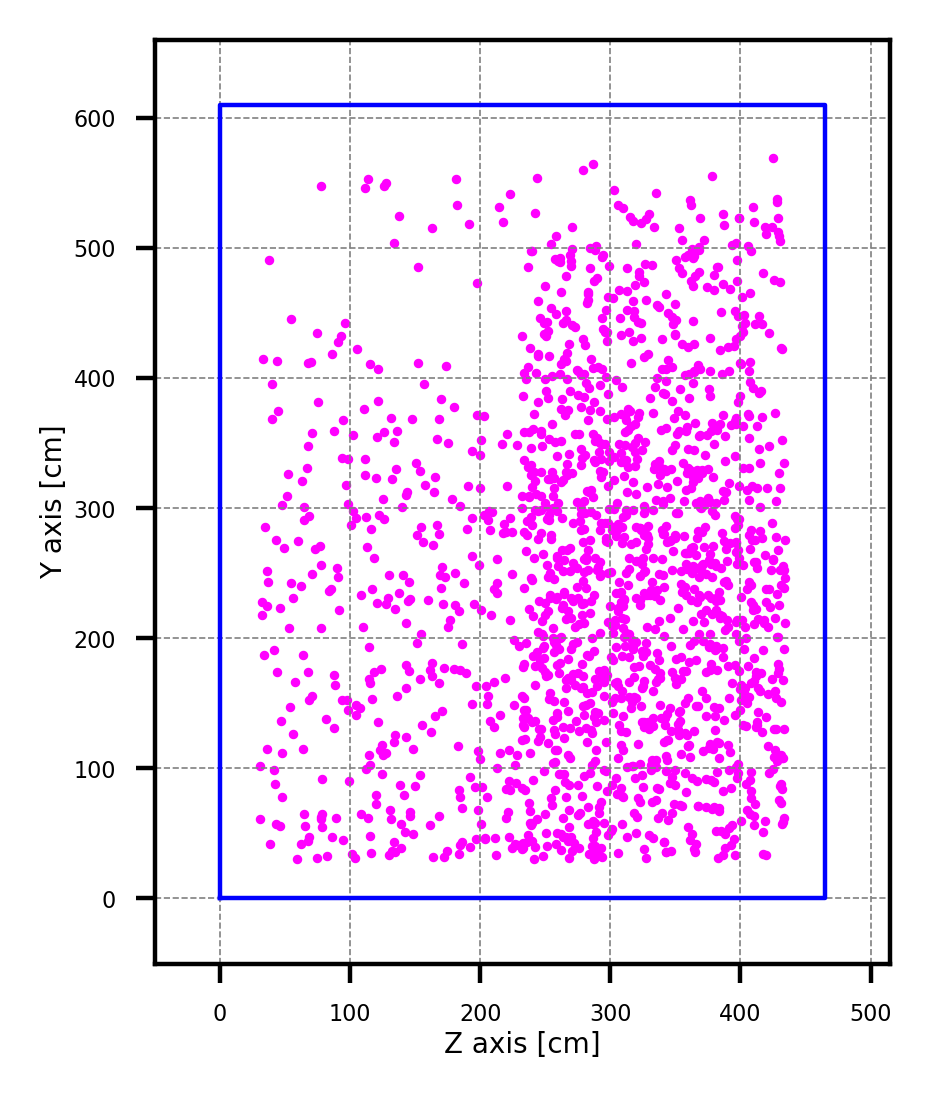

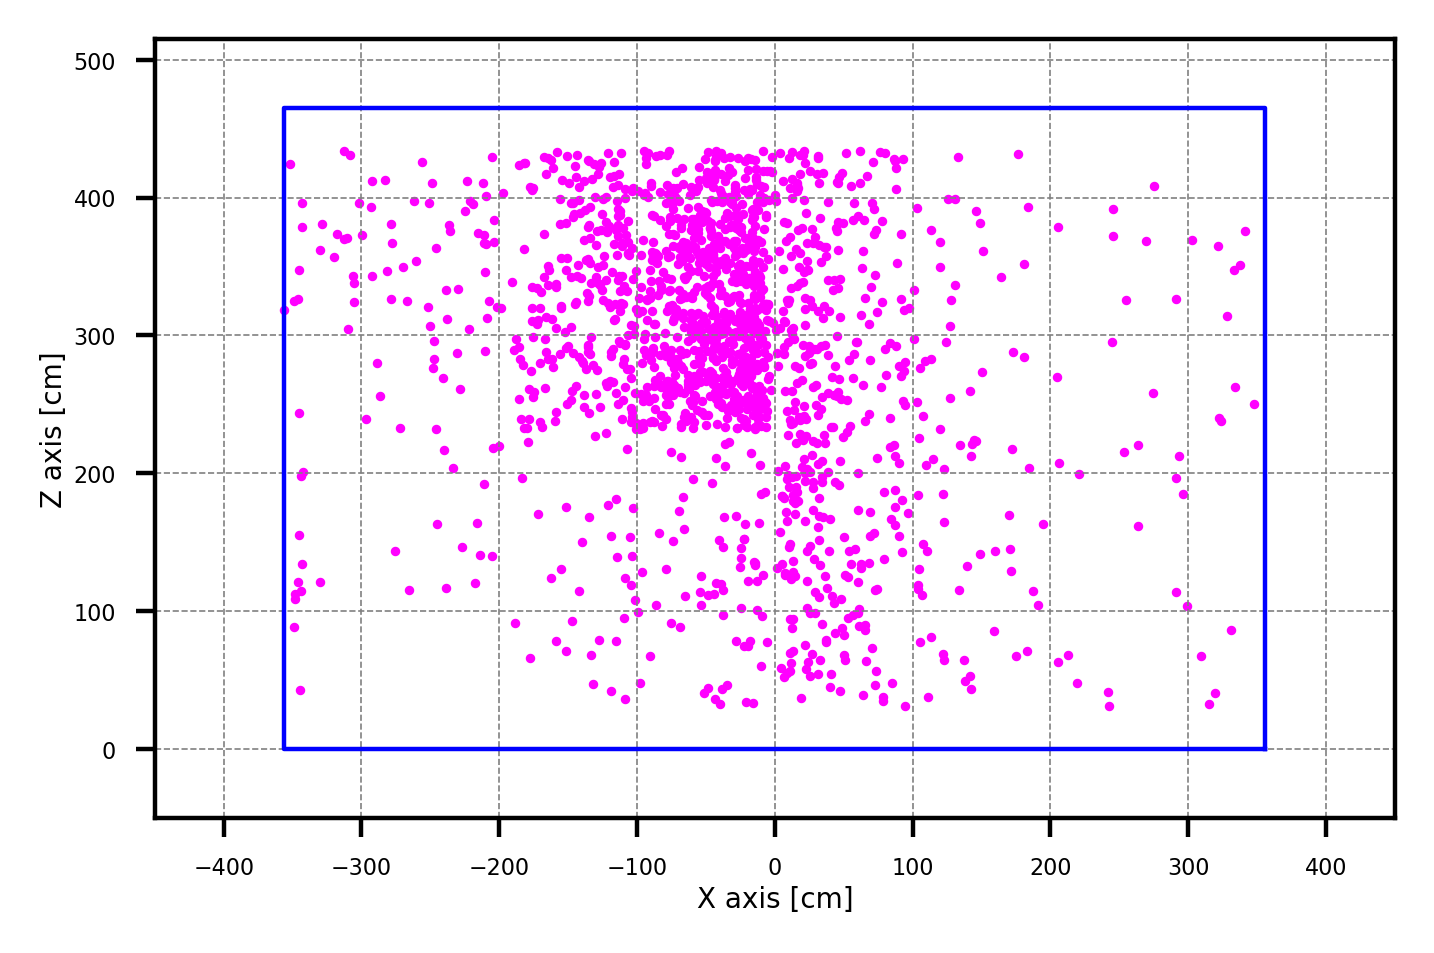

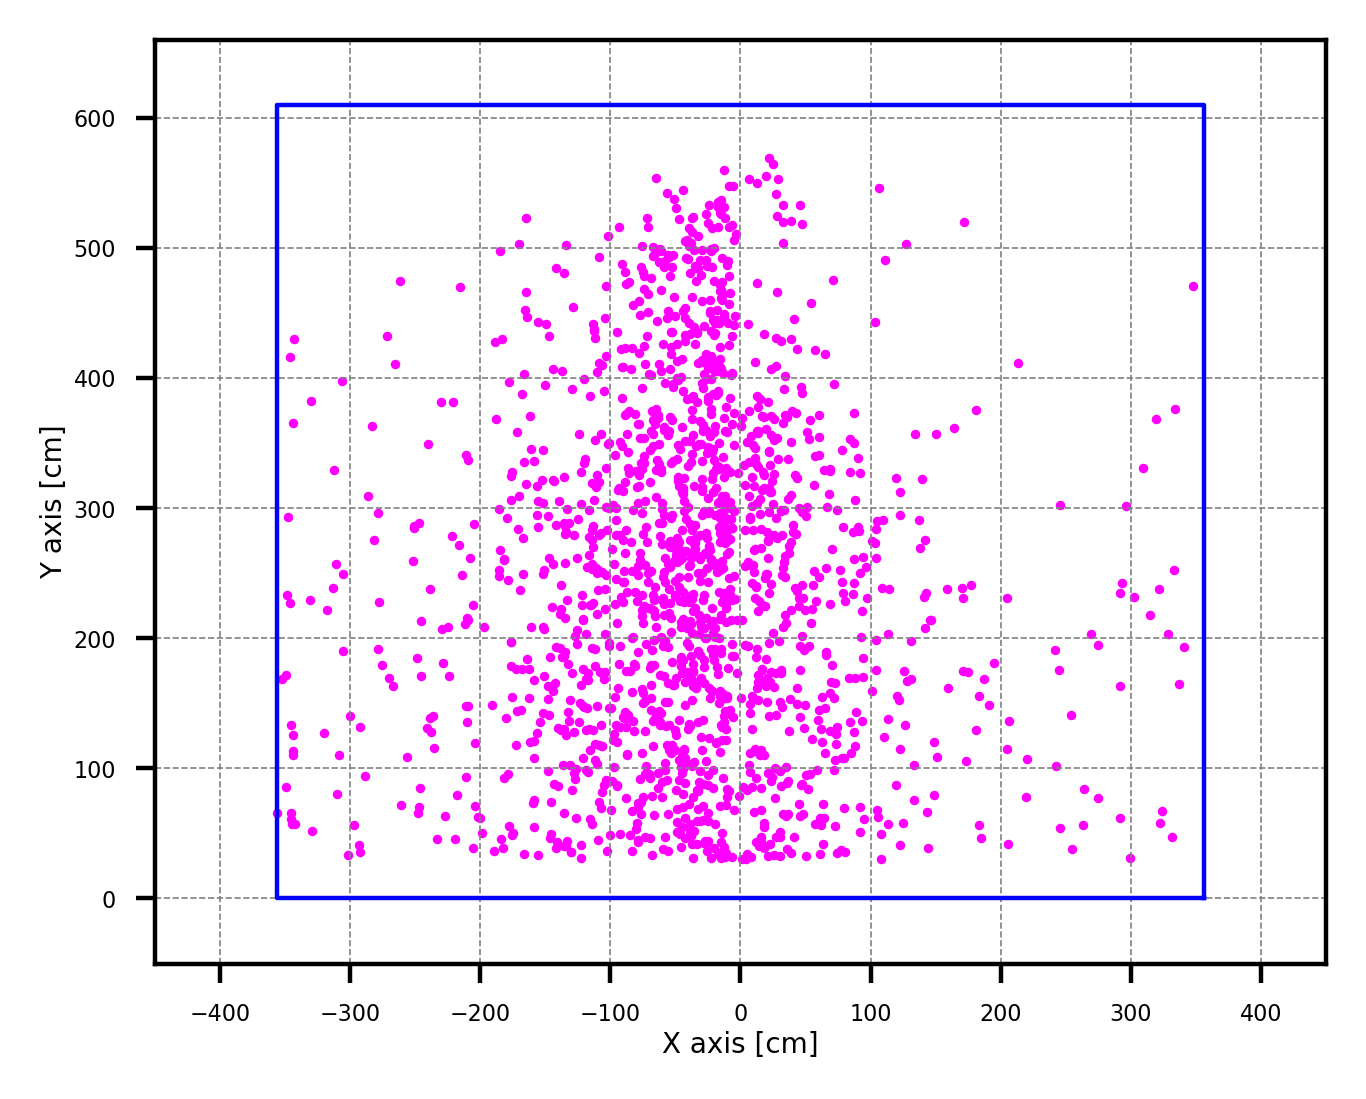

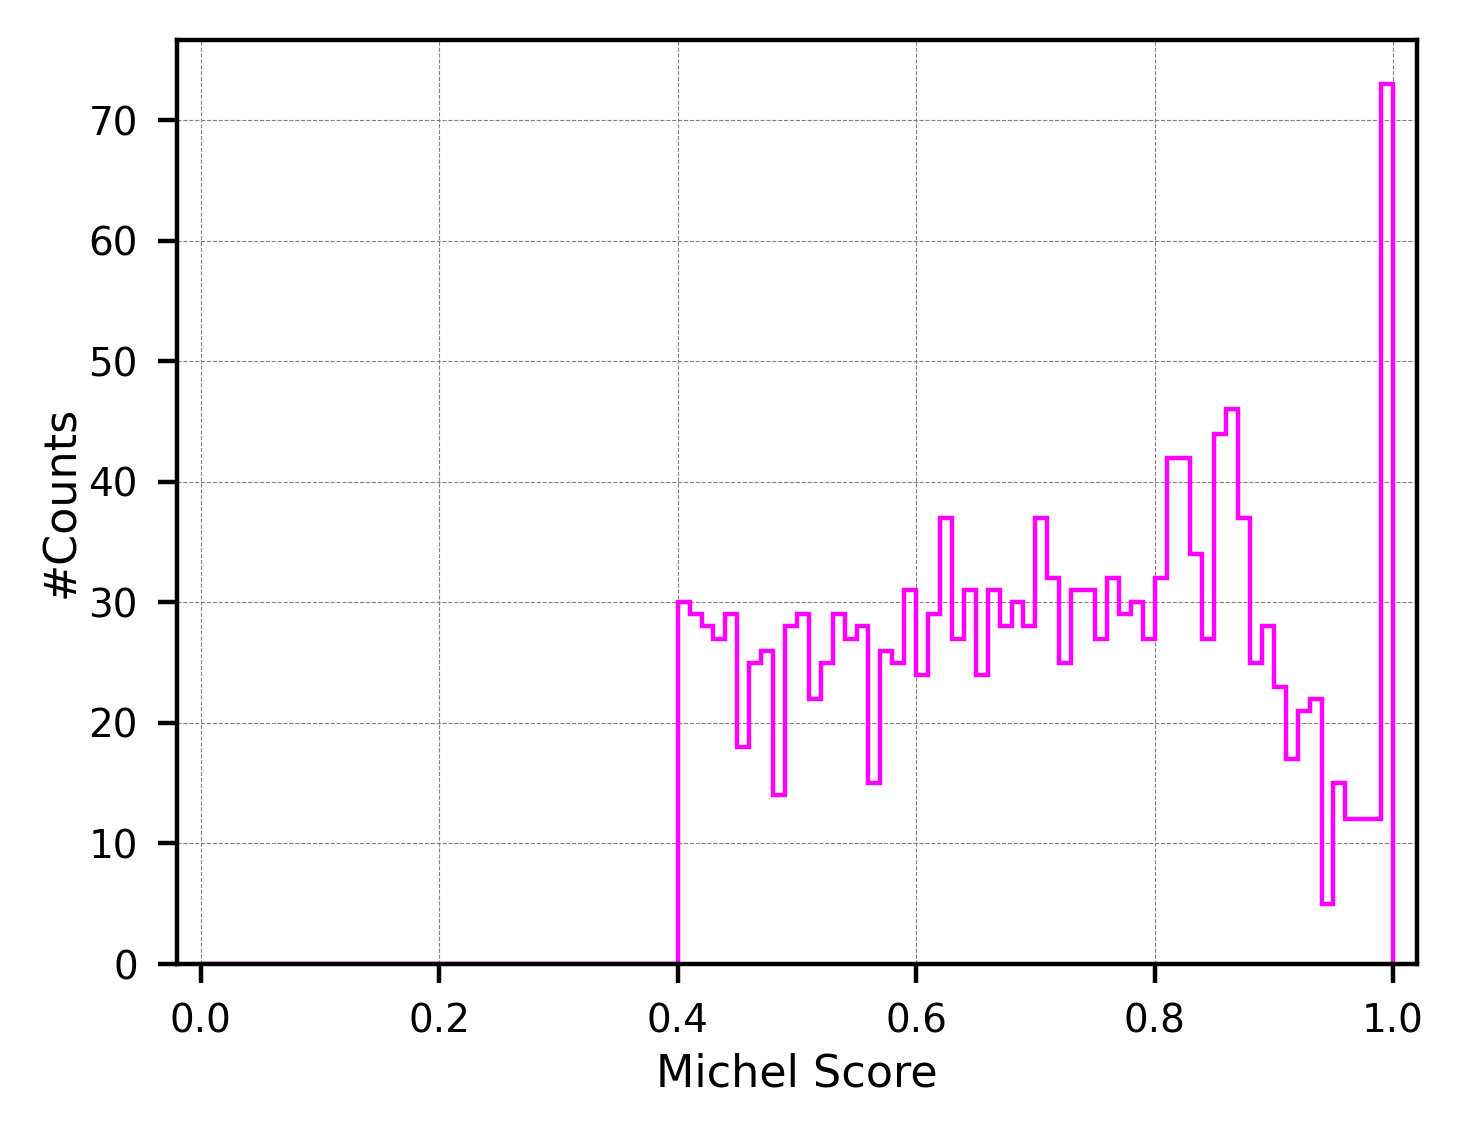

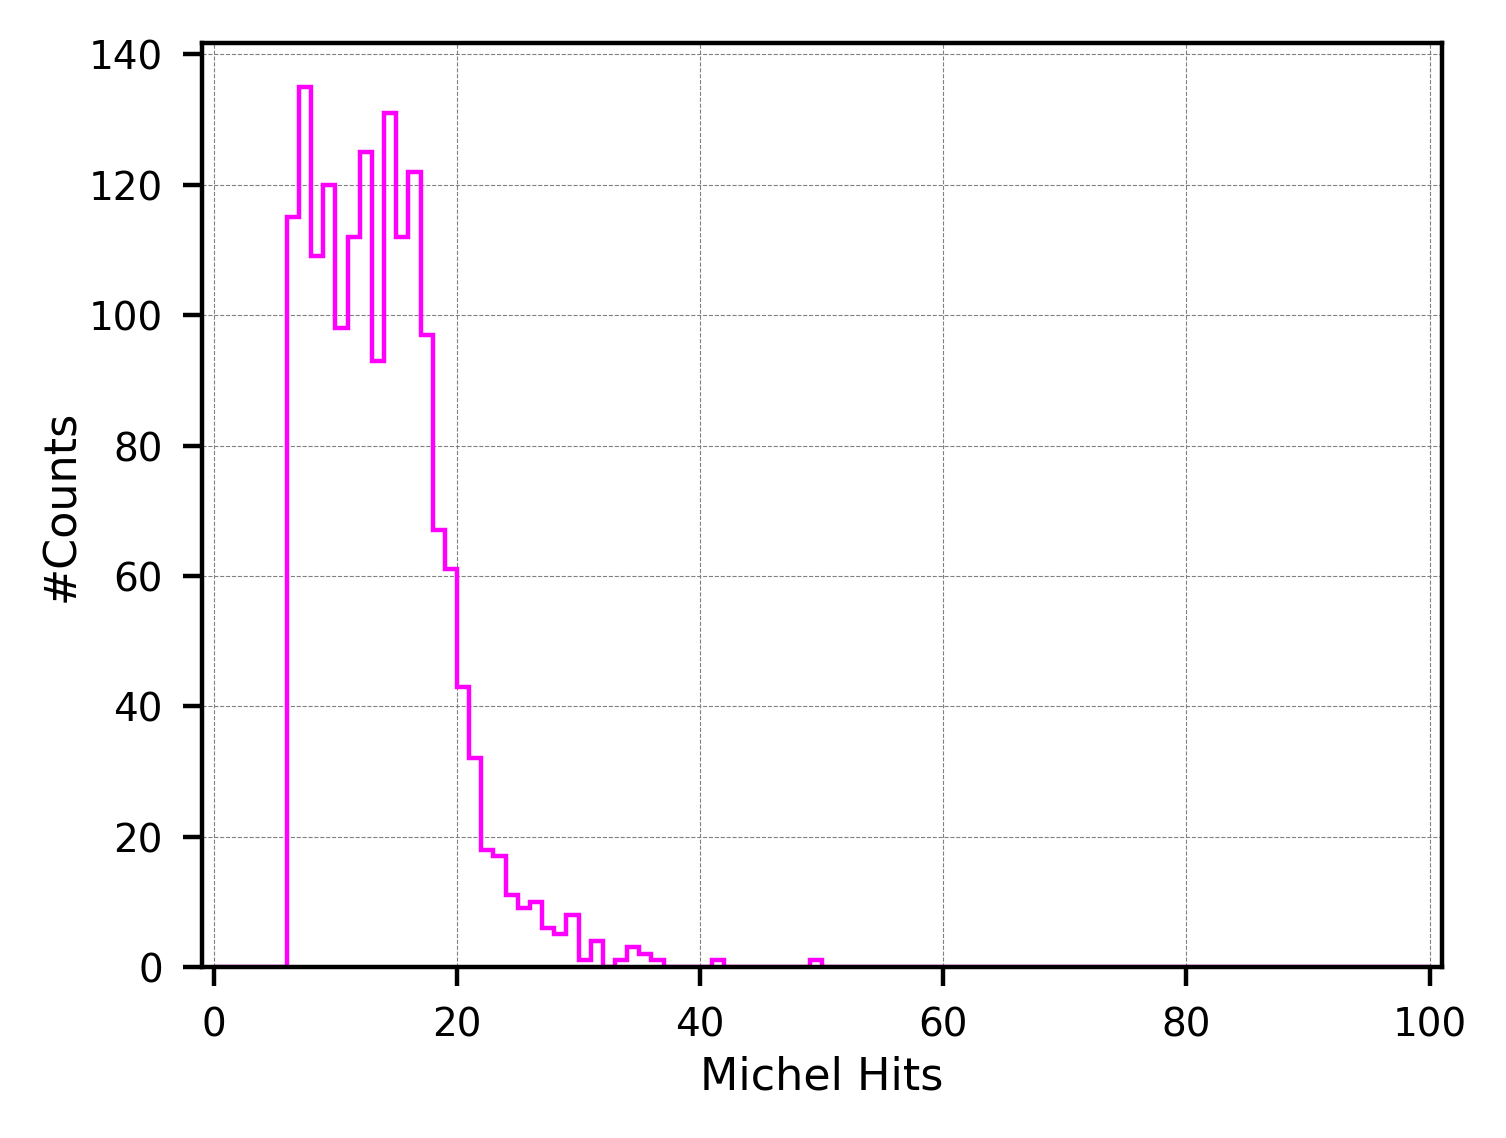

In [7]:
#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465





#Statistics for different distances-----------------------
count10 = 0
count10_50 = 0
count50_100 = 0
count100_200 = 0
count200_300 = 0
count300 = 0


  




# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-356, -356], [0, 1000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 1000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(decayX_filtered, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(-450, 540)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  







#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(decayZ_filtered, decayY_filtered, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()  







#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(decayX_filtered, decayZ_filtered, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 515)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 






#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(decayX_filtered, decayY_filtered, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 







#Michel score distribution (Original)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 0.01
range_min = 0
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(michelScore_filtered, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(-0.02, 1.02)
plt.xlabel('Michel Score', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 800)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  







#Michel hits distribution (Original)-----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(michelHits_filtered, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(-1, 101)
plt.xlabel('Michel Hits', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 800)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 

<br />
<br />
<br />



##  EventID and TrackID distribution

Repeated elements: [17364.0, 2352.0, 8088.0, 91563.0, 26244.0, 17195.0, 18448.0, 95137.0, 11062.0, 19445.0, 88598.0, 88848.0, 87155.0, 8436.0, 27035.0, 91187.0, 6019.0, 12608.0, 26301.0, 93842.0, 12082.0, 28001.0, 88016.0, 10440.0, 91642.0, 32016.0, 13785.0, 6582.0, 5304.0, 28581.0, 3996.0, 13839.0, 12110.0, 15010.0, 20066.0, 11303.0, 8321.0, 6850.0, 9752.0, 24559.0, 6886.0]
Number of repeated elements:  41 (2.455%)


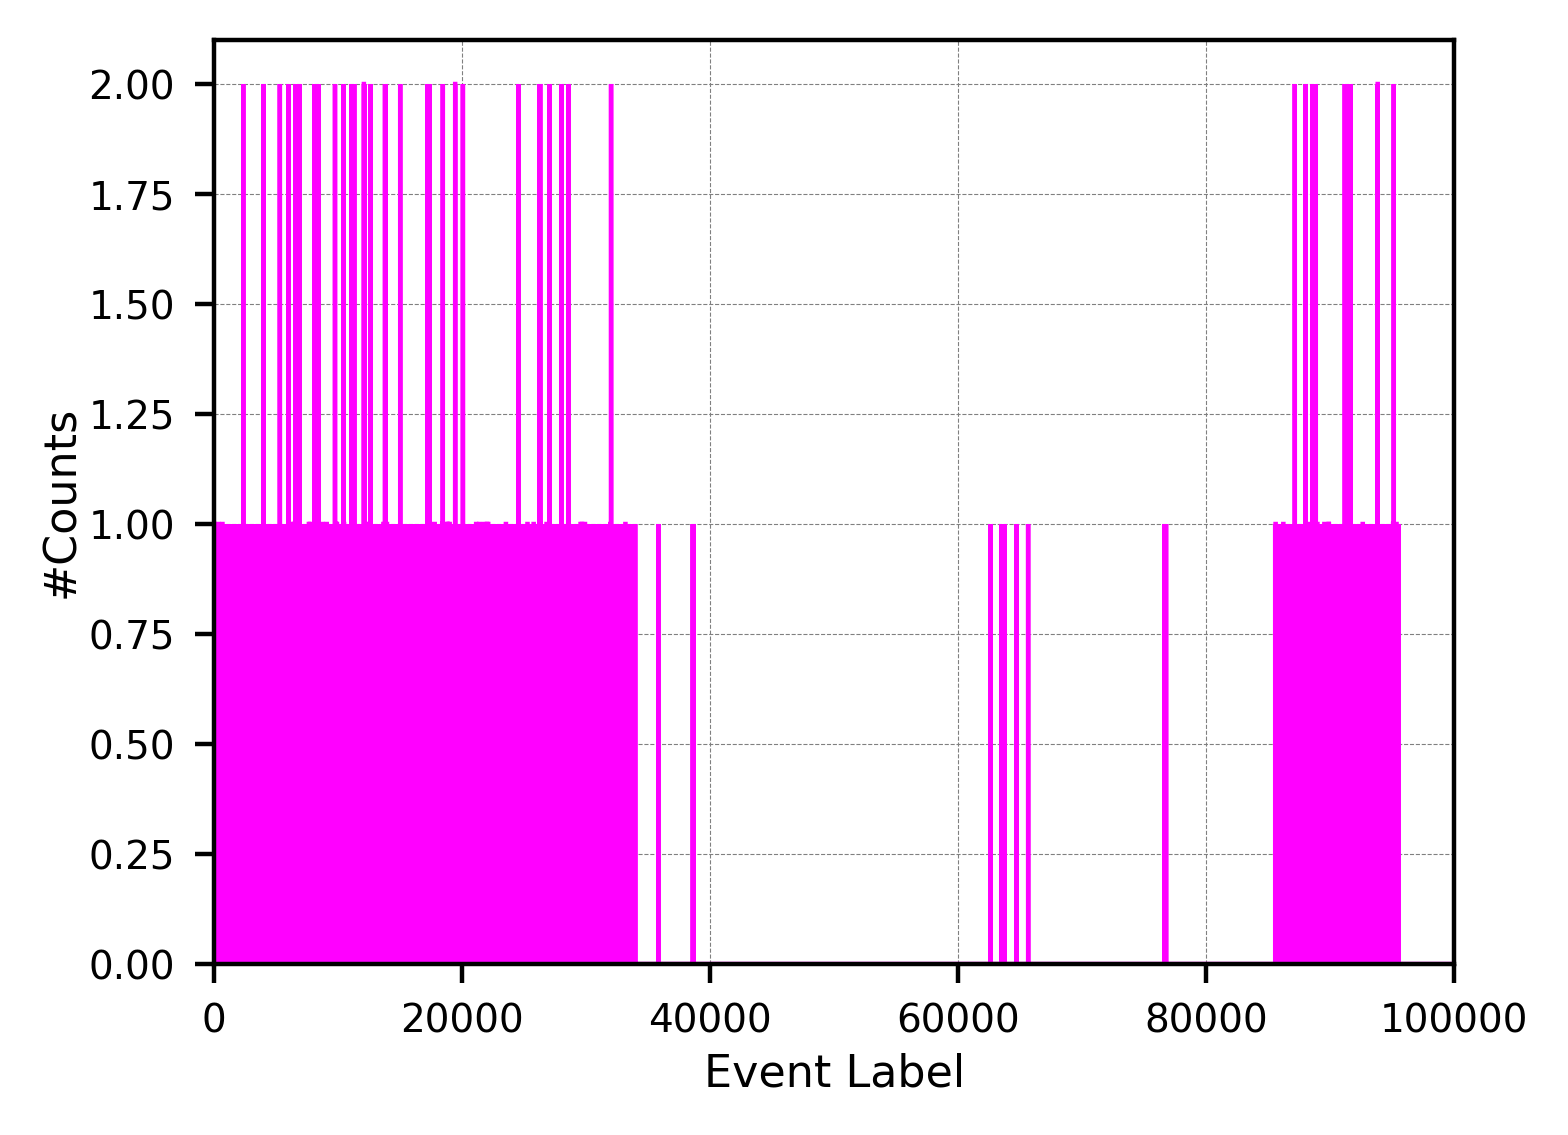

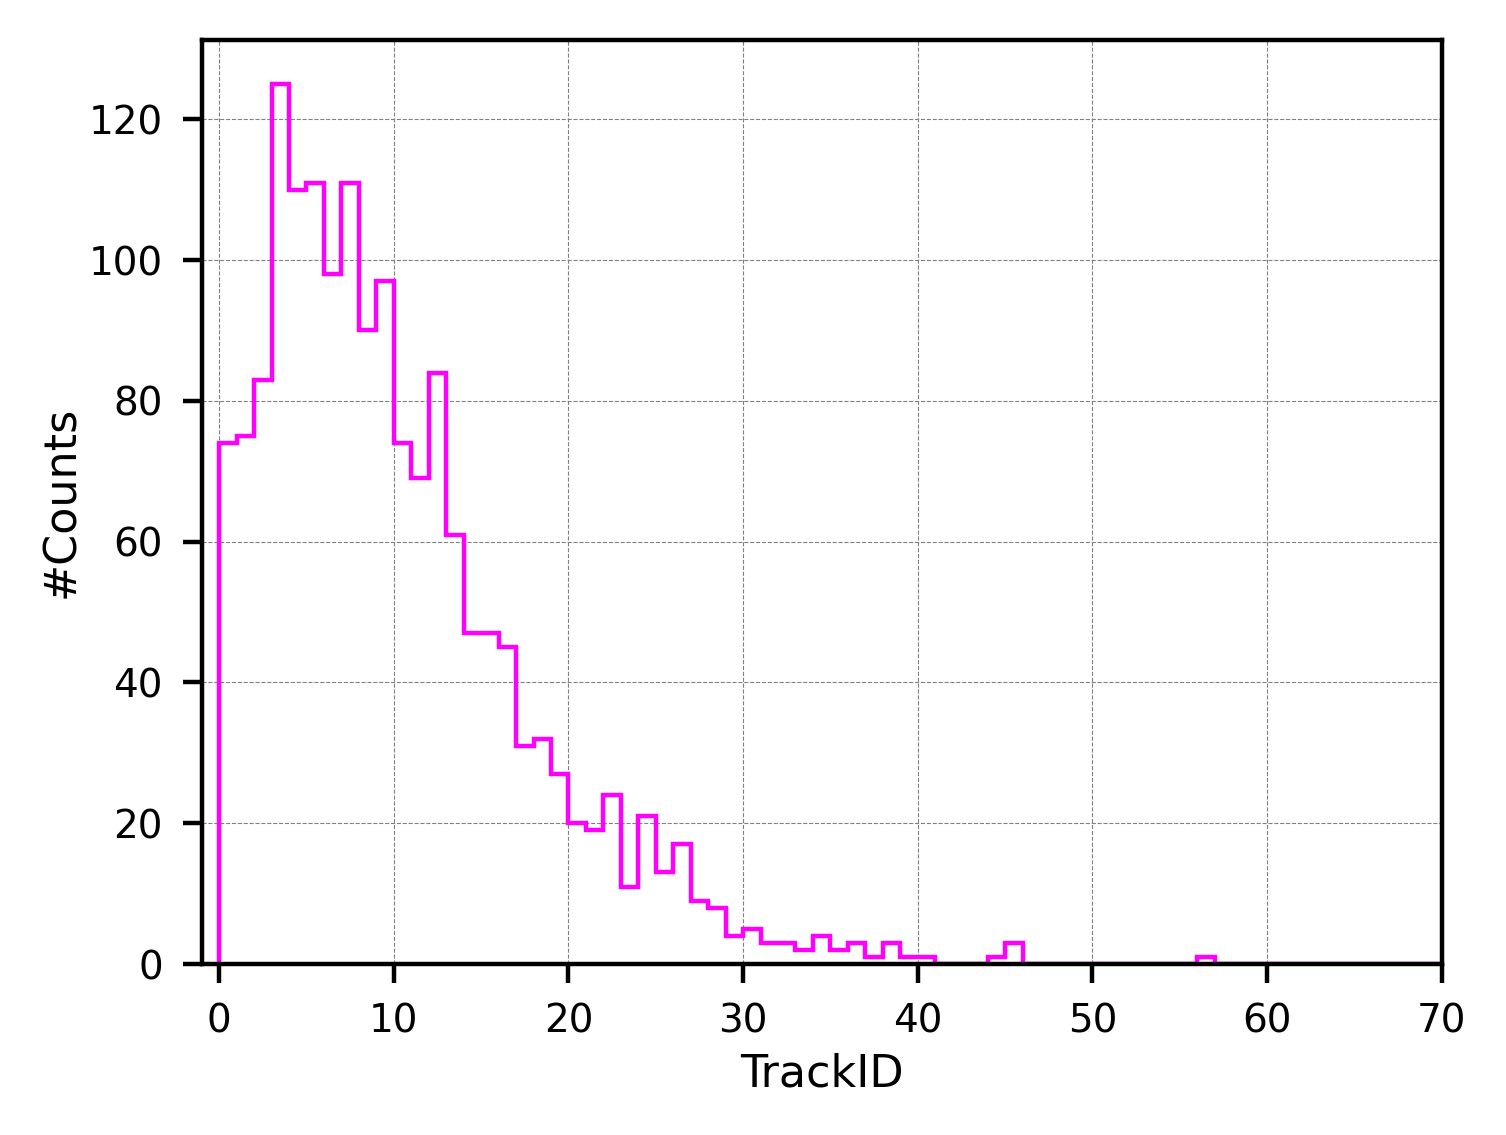

In [20]:
from collections import Counter


#Count occurrences of each element
counts = Counter(eventID)

#Filter elements with a count greater than 1
repeated_elements = [elem for elem, count in counts.items() if count > 1]
print("Repeated elements:", repeated_elements)
print("Number of repeated elements: ", len(repeated_elements), "({:.3f}%)".format(len(repeated_elements)/len(eventID)*100))






# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100000
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(eventID, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(0, 100000)
plt.xlabel('Event Label', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  





# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 70
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(trackID, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(-1, 70)
plt.xlabel('TrackID', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 



In [ ]:
#Statistics for different distances-----------------------
count10 = 0
count10_50 = 0
count50_100 = 0
count100_200 = 0
count200_300 = 0
count300 = 0

for value in cutX:
    #APA planes are at x=-356 & x=356
    if  value <= -346 or value >= 346:
        count10 += 1
    elif -346 < value <= -306 or 306 <= value < 346:
        count10_50 += 1
    elif -306 < value <= -256 or 256 <= value < 306:
        count50_100 += 1 
    elif -256 < value <= -156 or 156 <= value < 256:
        count100_200 += 1    
    elif -156 < value <= -56 or 56 <= value < 156:
        count200_300 += 1 
    else:
        count300 += 1

# Output the counts
print("Distance to APAs    [0, 10]: ", count10)
print("Distance to APAs   (10, 50]: ", count10_50)
print("Distance to APAs  (50, 100]: ", count50_100)
print("Distance to APAs (100, 200]: ", count100_200)
print("Distance to APAs (200, 300]: ", count200_300)
print("Distance to APAs (300, inf): ", count300)

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

###  Explore asymmetry of X didtribution:

In [24]:
leftSX = [] #left start X---
leftSY = [] #left start Y---
leftSZ = [] #left start Z---
leftDX = [] #left decay X---
leftDY = []
leftDZ = []

rightSX = [] #left start X---
rightSY = [] #left start Y---
rightSZ = [] #left start Z---
rightDX = [] #left decay X---
rightDY = []
rightDZ = []



for i in range(0, len(decayX)):
    sX = startX[i]
    eX = decayX[i]
    sY = startY[i]
    sZ = startZ[i]
    eY = decayY[i]
    eZ = decayZ[i]
    
    if sX <= eX:
        leftSX.append(sX)
        leftSY.append(sY)
        leftSZ.append(sZ)
        leftDX.append(eX)
        leftDY.append(eY)
        leftDZ.append(eZ)
    else:
        rightSX.append(sX)
        rightSY.append(sY)
        rightSZ.append(sZ)
        rightDX.append(eX)
        rightDY.append(eY)
        rightDZ.append(eZ)        


print("# of left-emitted particles : ", len(leftSX))
print("# of right-emitted particles: ", len(rightSX))
print("Total particles (left + right): ", len(leftSX)+len(rightSX))
print("Initial particles: ", len(decayX))


    

# of left-emitted particles :  3762
# of right-emitted particles:  7951
Total particles (left + right):  11713
Initial particles:  11713


<br />
<br />

###  Left-emitted particles:

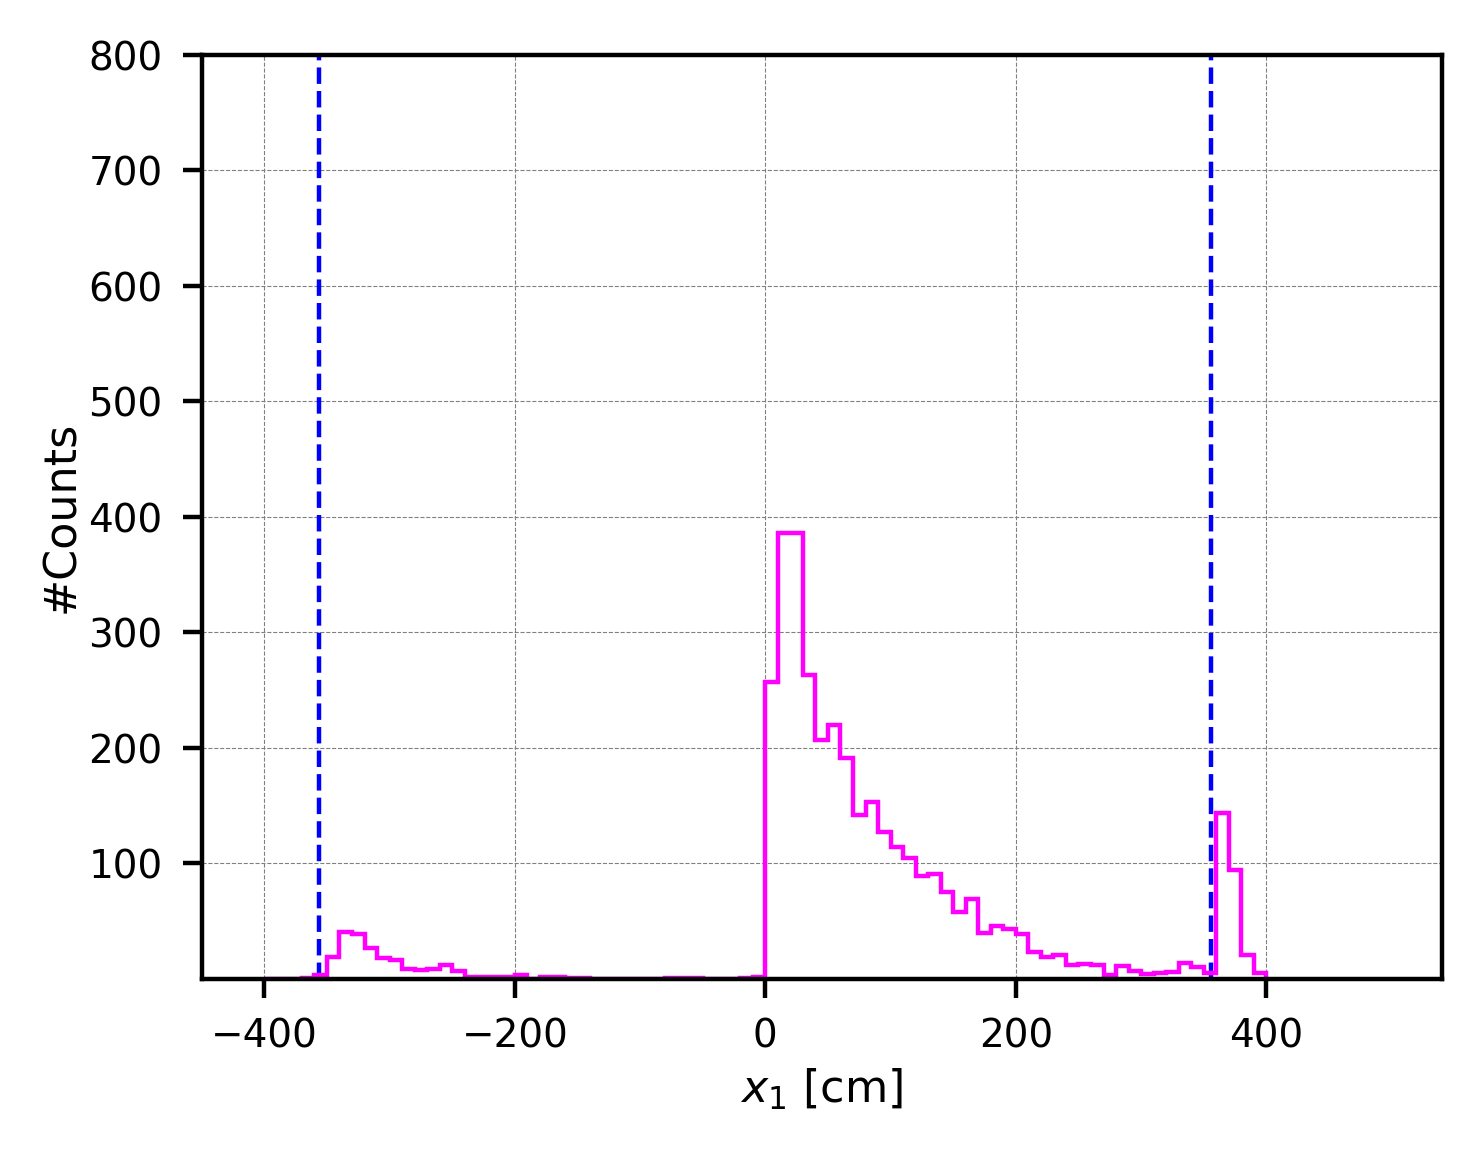

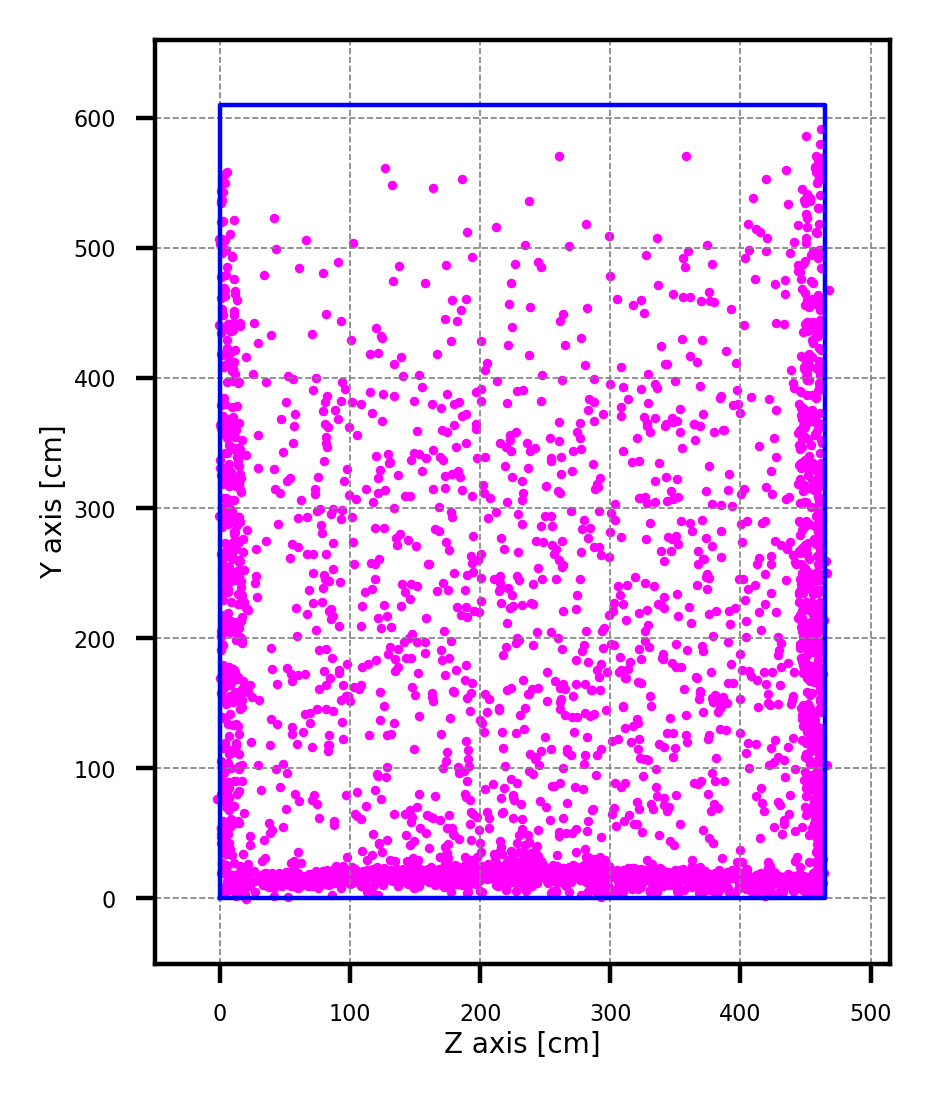

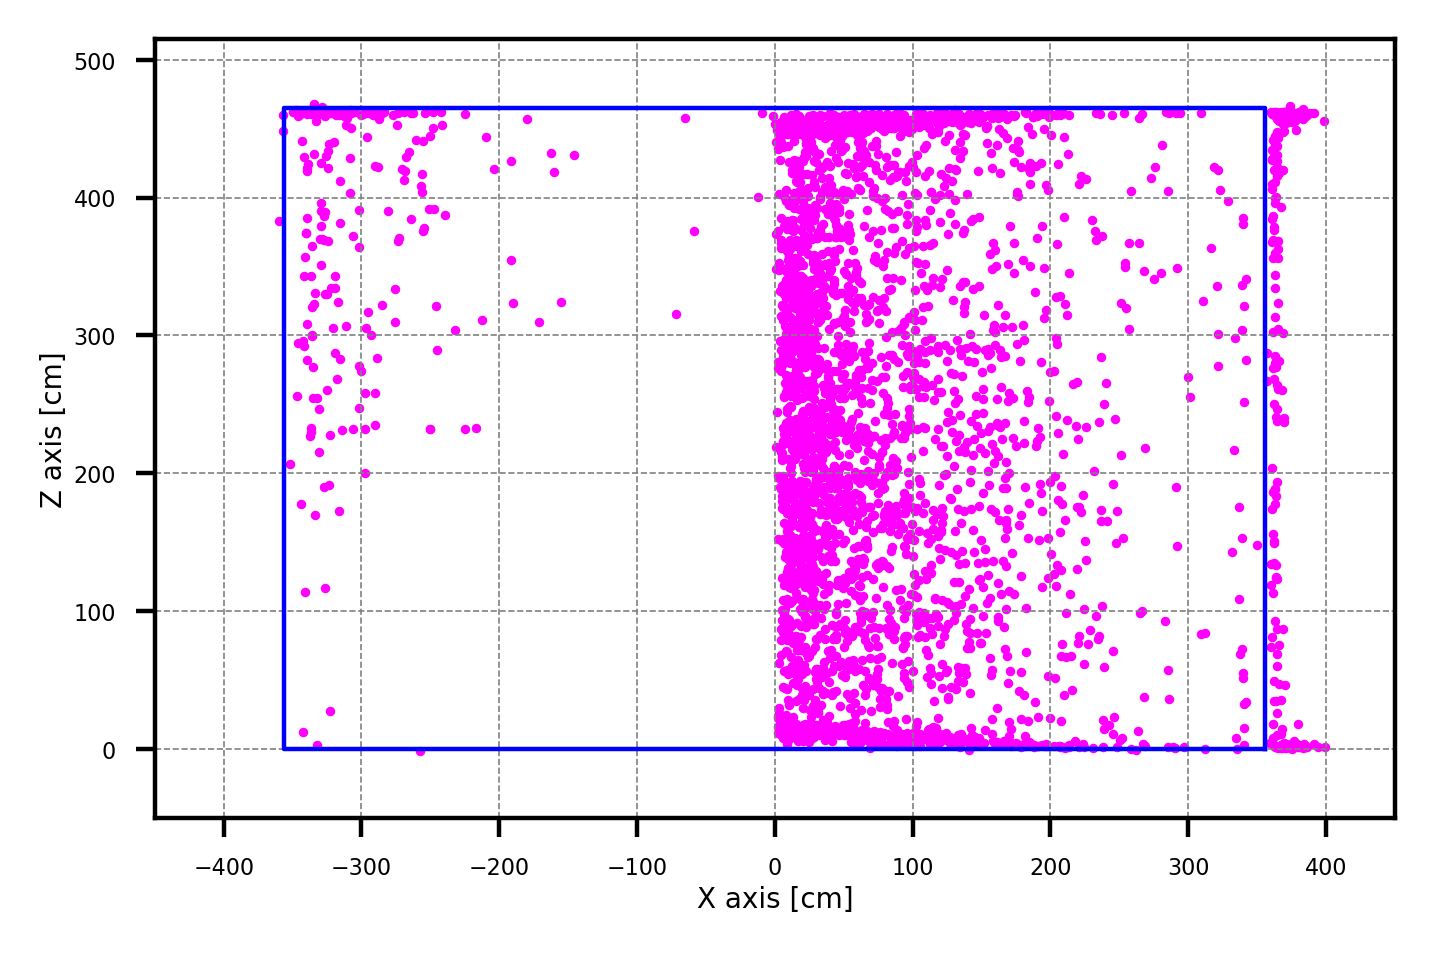

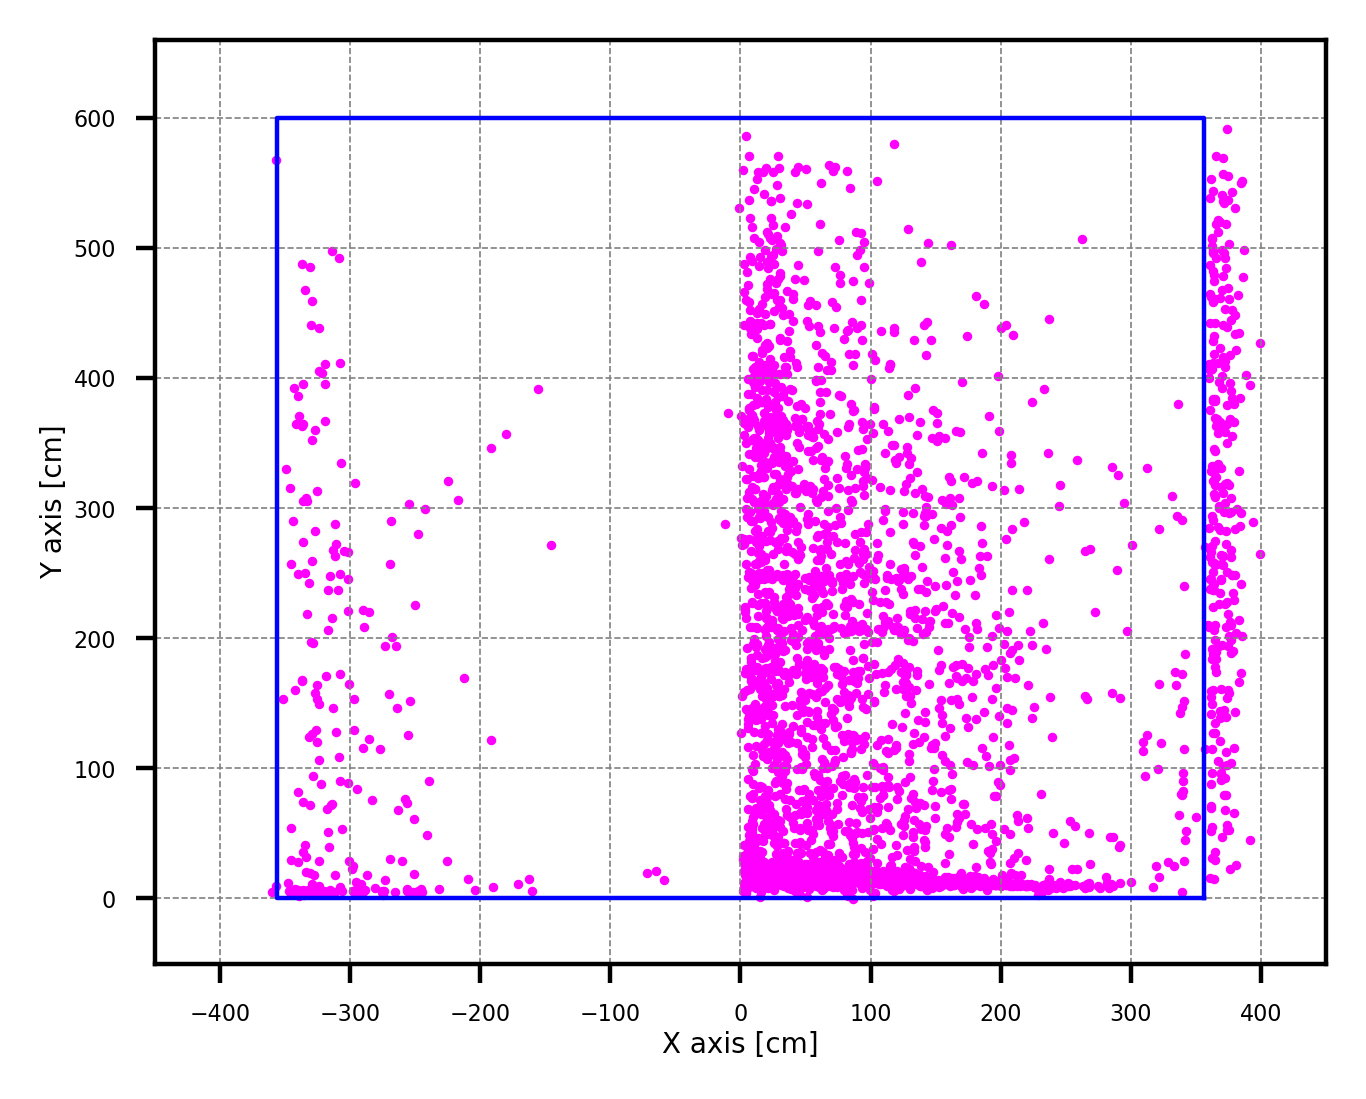

In [31]:
# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-356, -356], [0, 800], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 800], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(leftDX, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(-450, 540)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 800)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  







#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(leftDZ, leftDY, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()  







#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(leftDX, leftDZ, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 515)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 






#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(leftDX, leftDY, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 

<br />
<br />

###  Right-emitted particles:

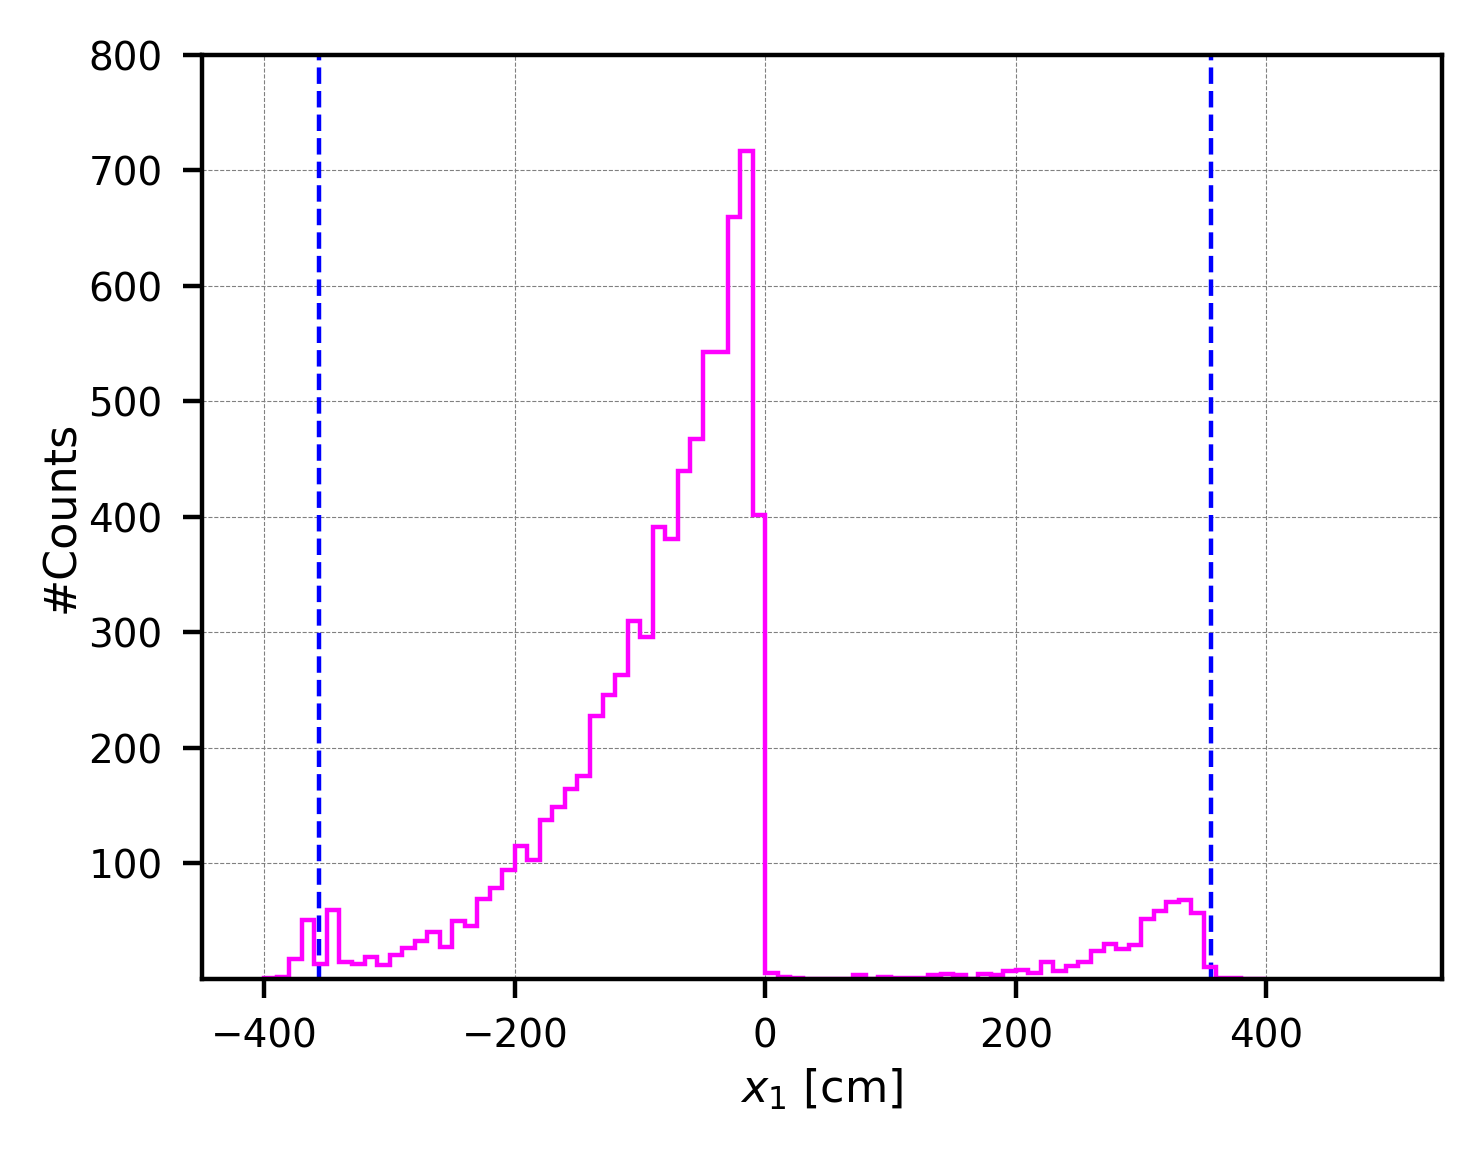

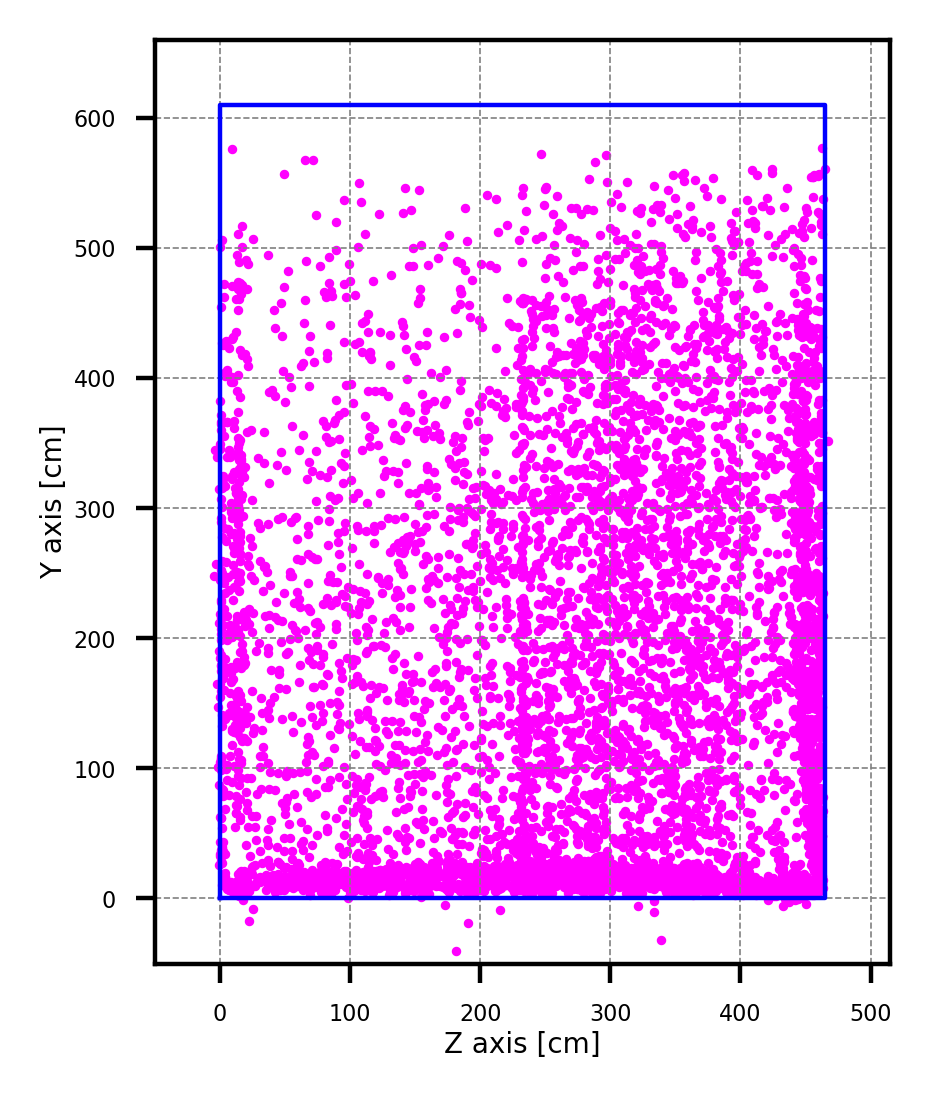

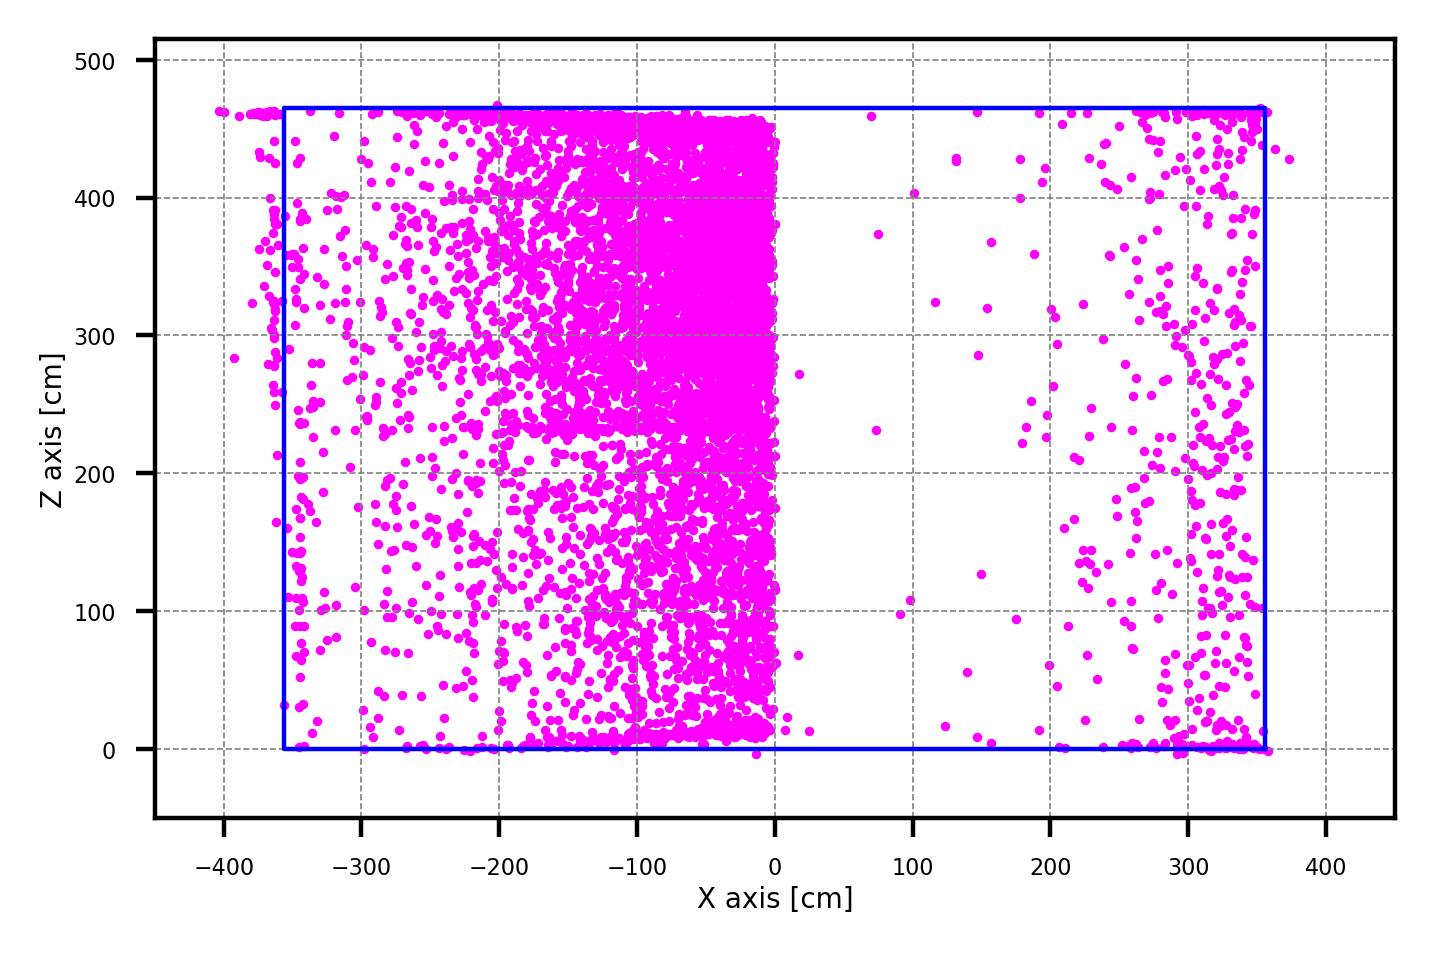

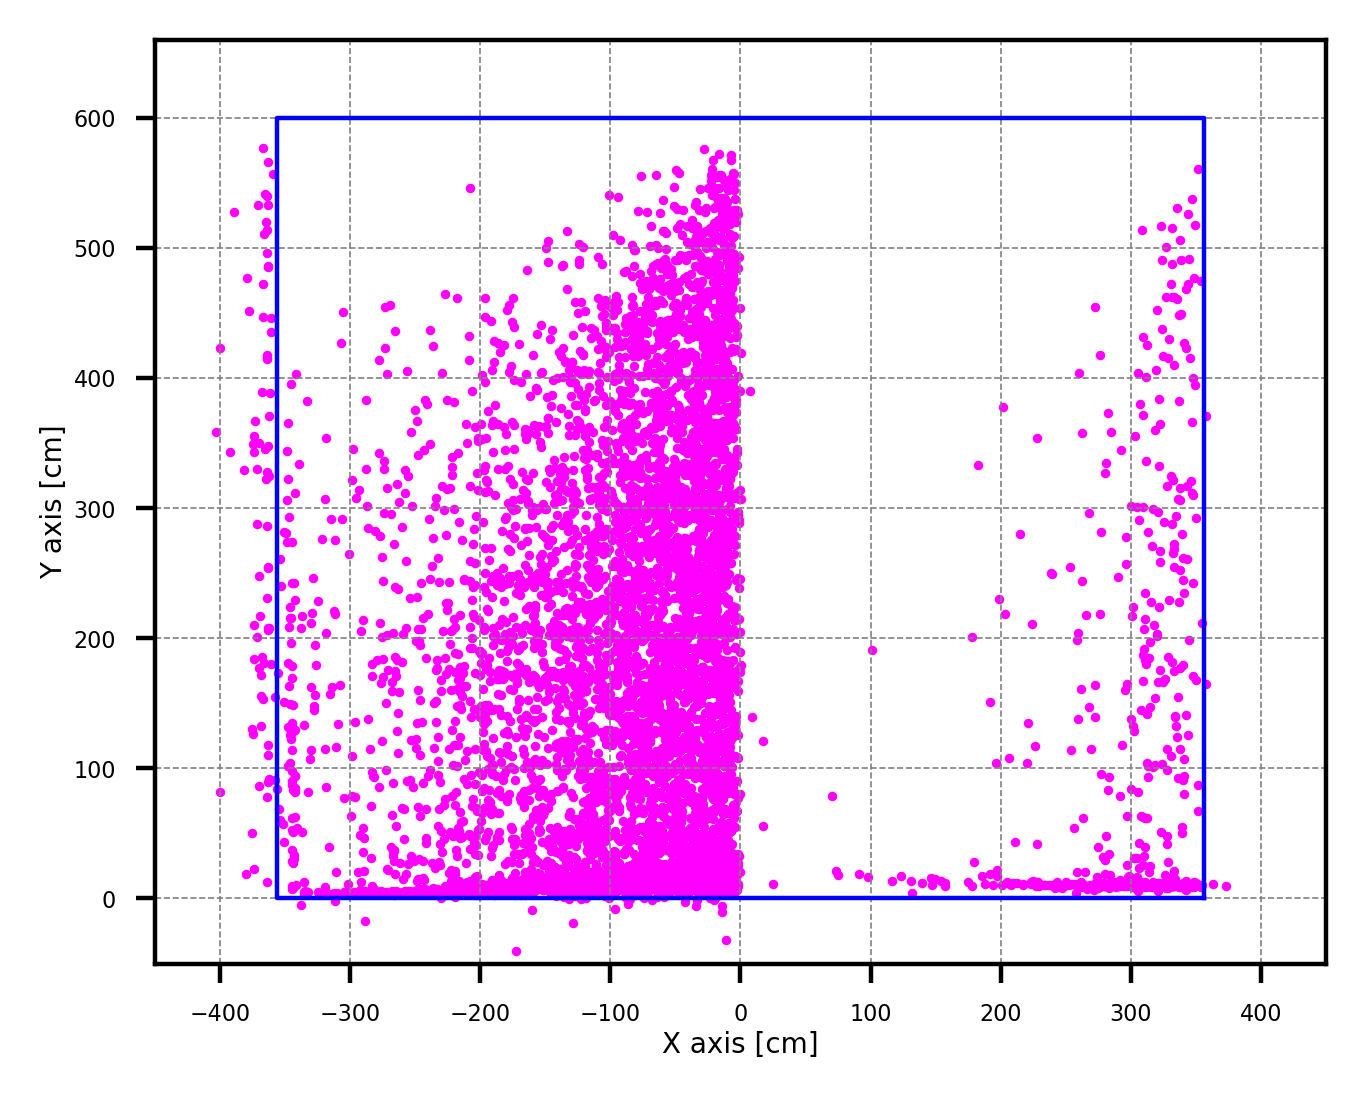

In [34]:
# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-356, -356], [0, 800], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 800], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(rightDX, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(-450, 540)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 800)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  







#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(rightDZ, rightDY, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()  







#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(rightDX, rightDZ, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 515)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 






#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(rightDX, rightDY, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 

<br />
<br />

###  Distributions of  Starting points:

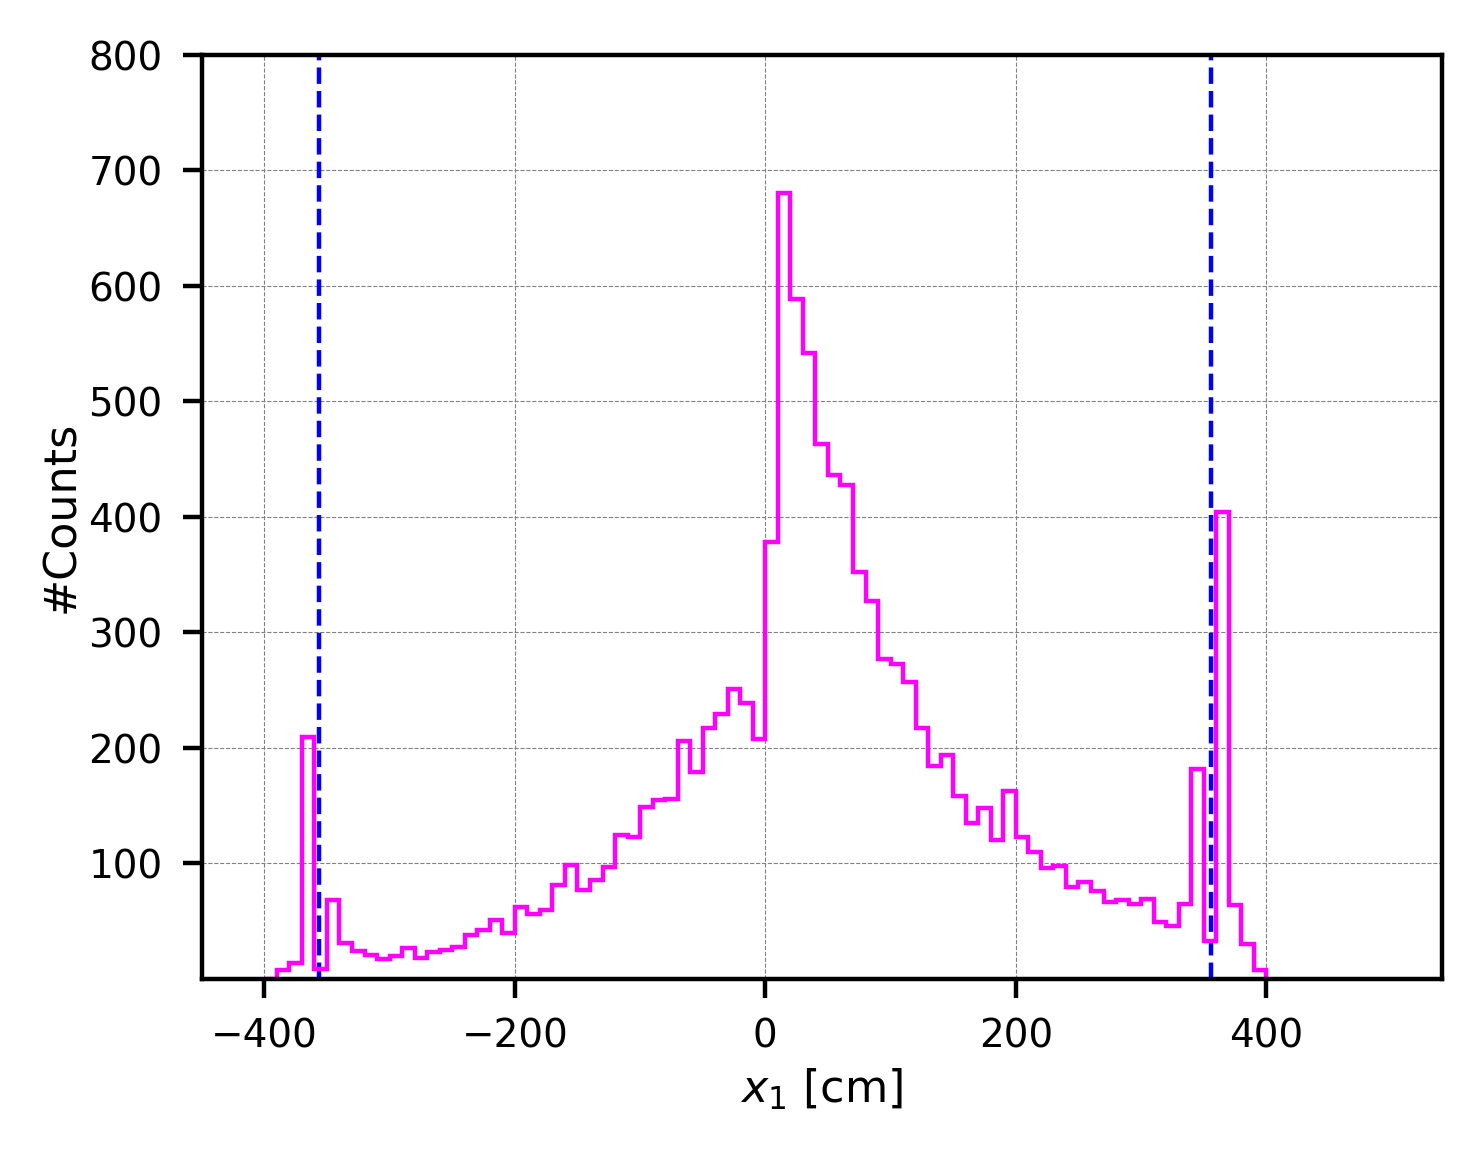

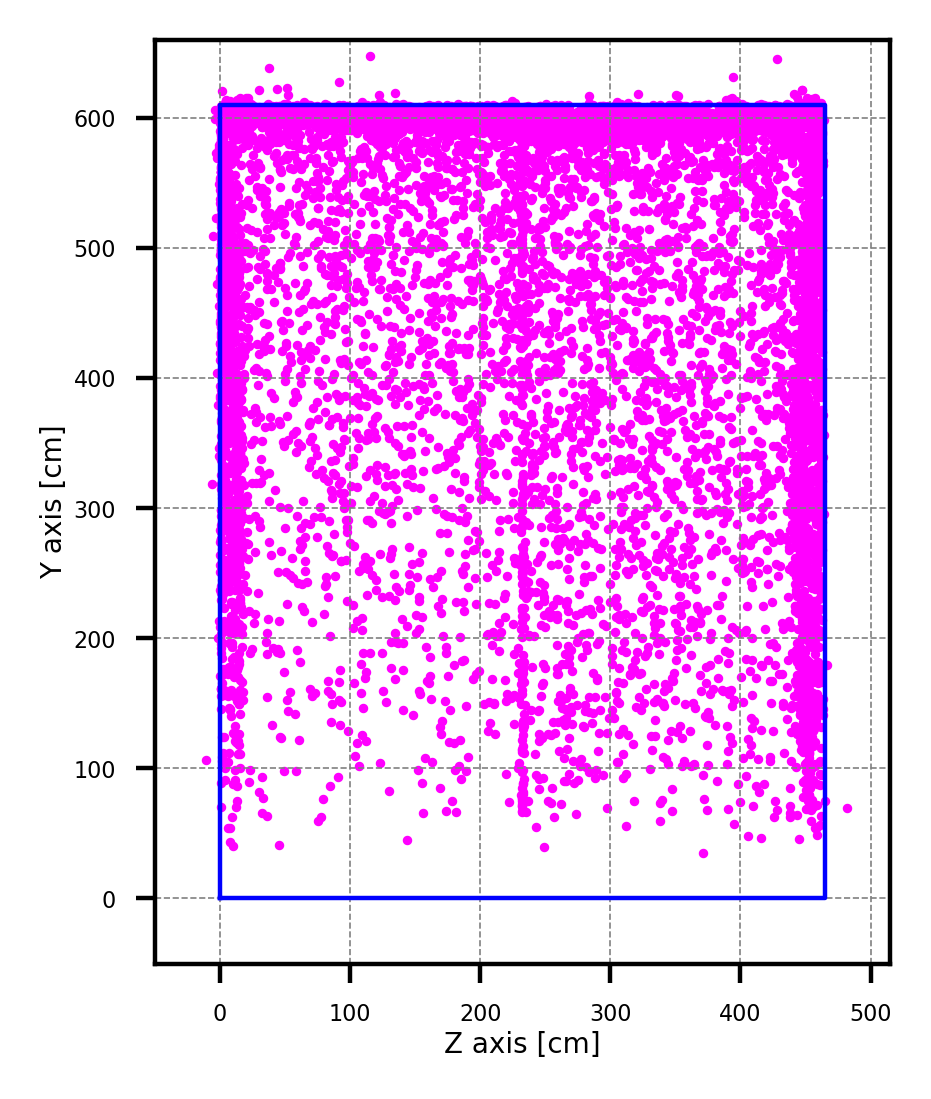

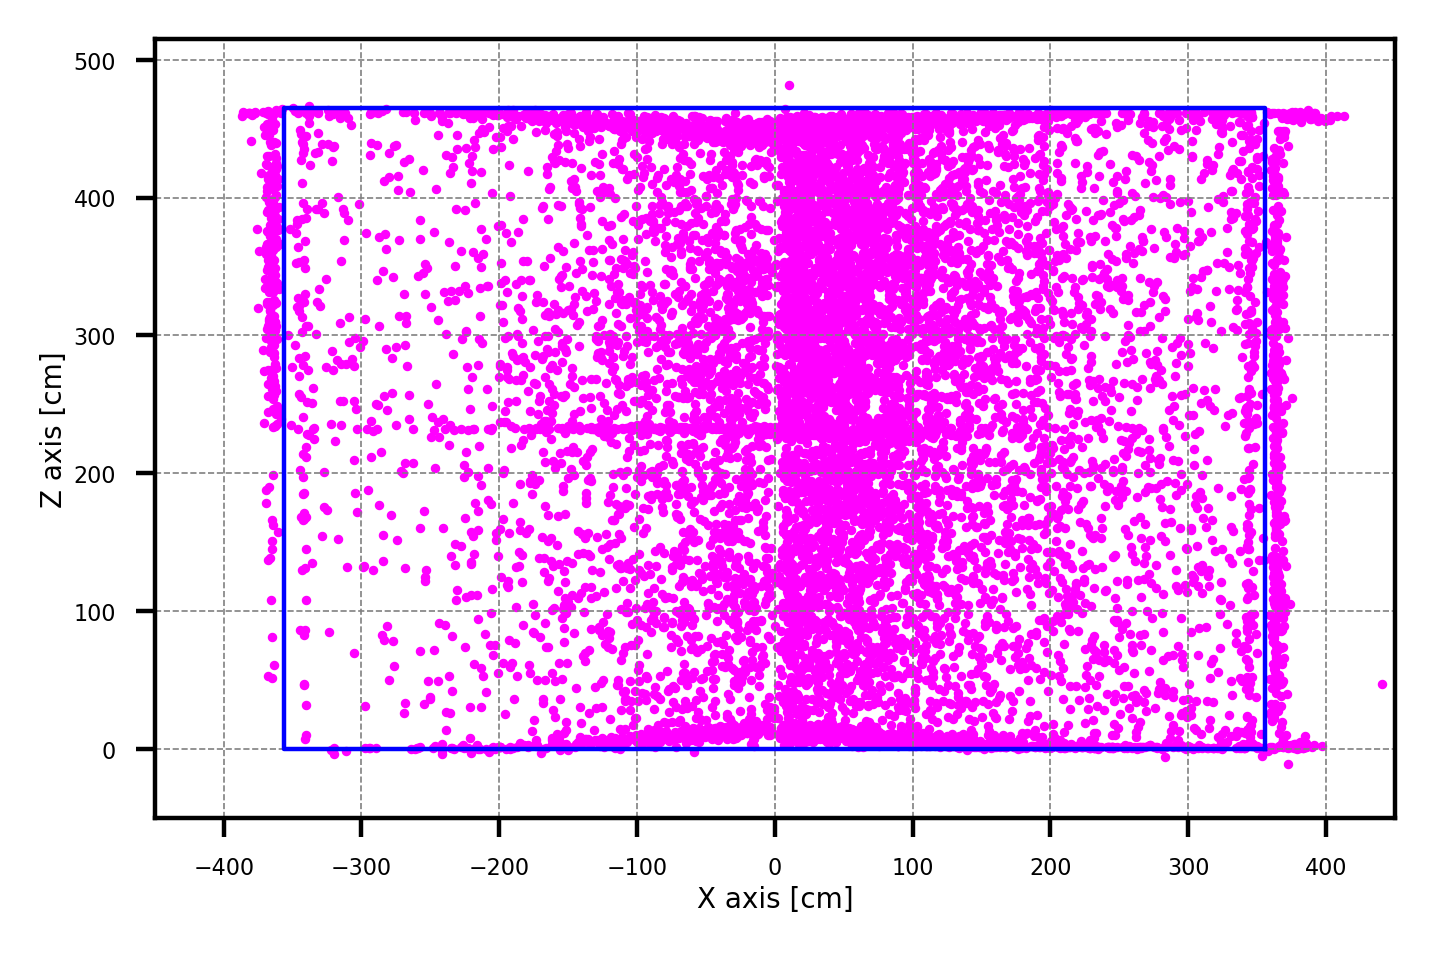

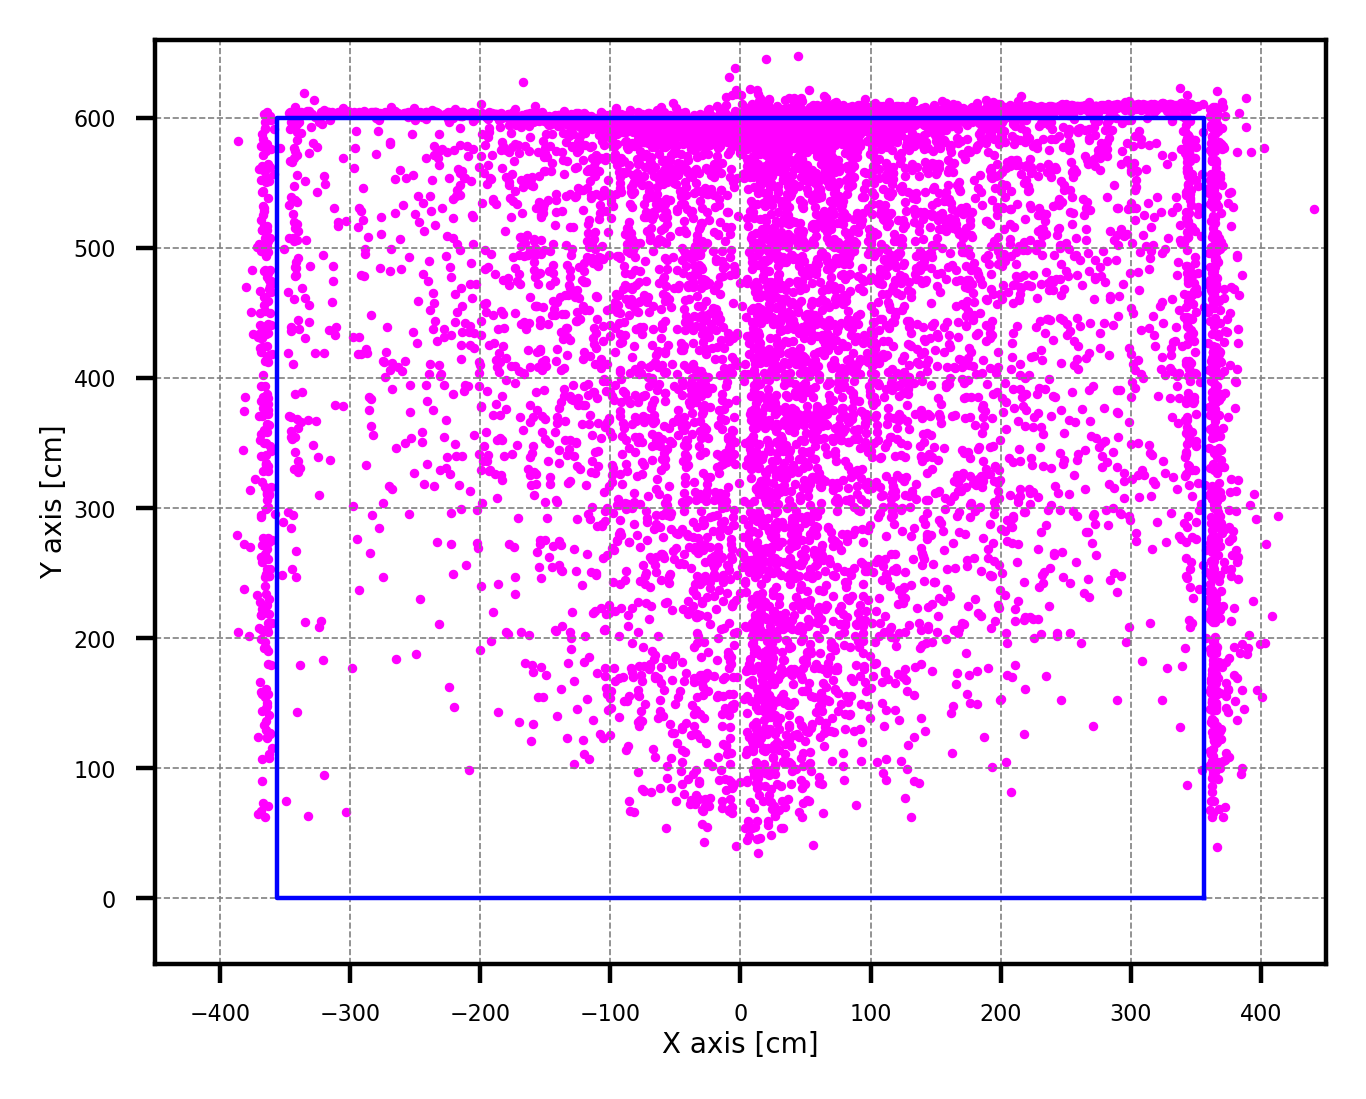

In [3]:
#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465







# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-356, -356], [0, 800], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 800], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(startX, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(-450, 540)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 800)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  







#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(startZ, startY, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()  







#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(startX, startZ, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 515)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 






#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(startX, startY, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




<br />
<br />

###  Remove Edge points:

Size of cutX:  4862
Size of cutY:  4862
Size of cutZ:  4862
Distance to APAs    [0, 10]:  162
Distance to APAs   (10, 50]:  184
Distance to APAs  (50, 100]:  127
Distance to APAs (100, 200]:  472
Distance to APAs (200, 300]:  1656
Distance to APAs (300, inf):  2261


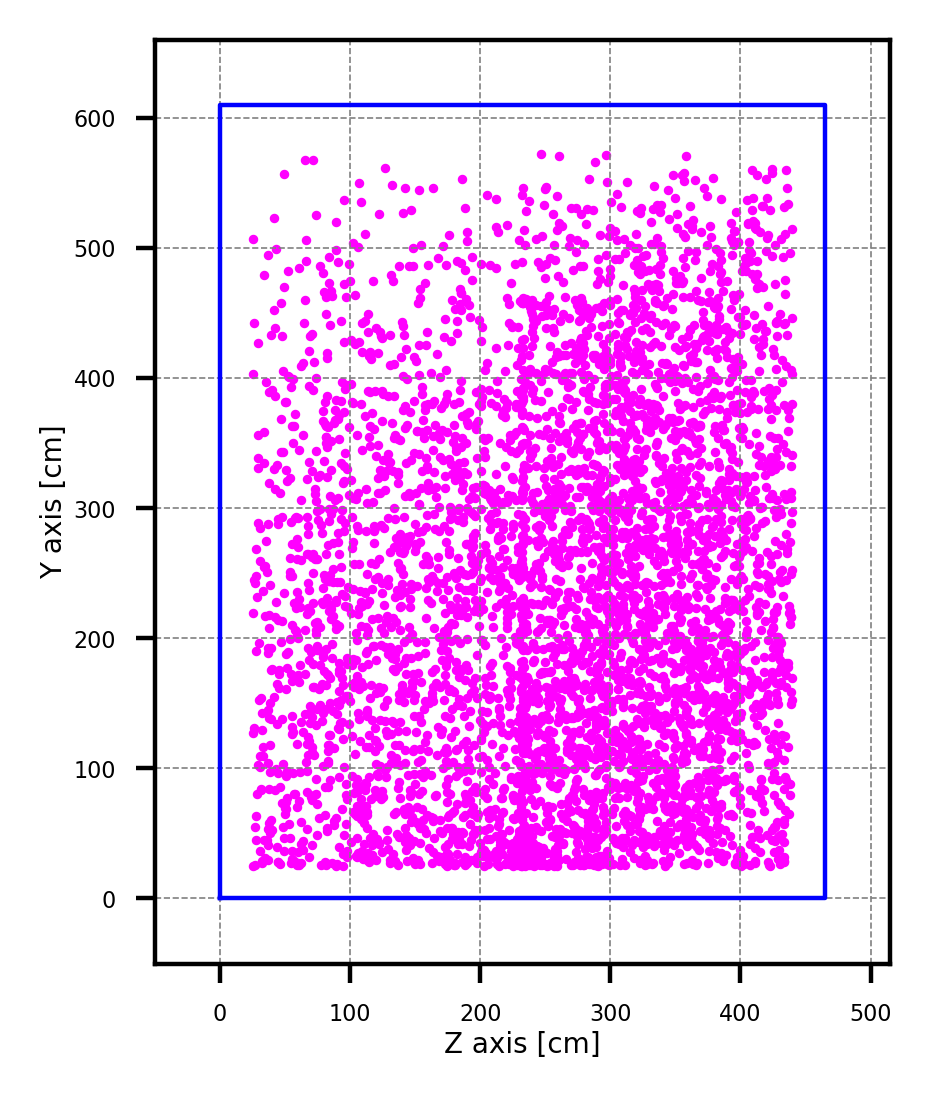

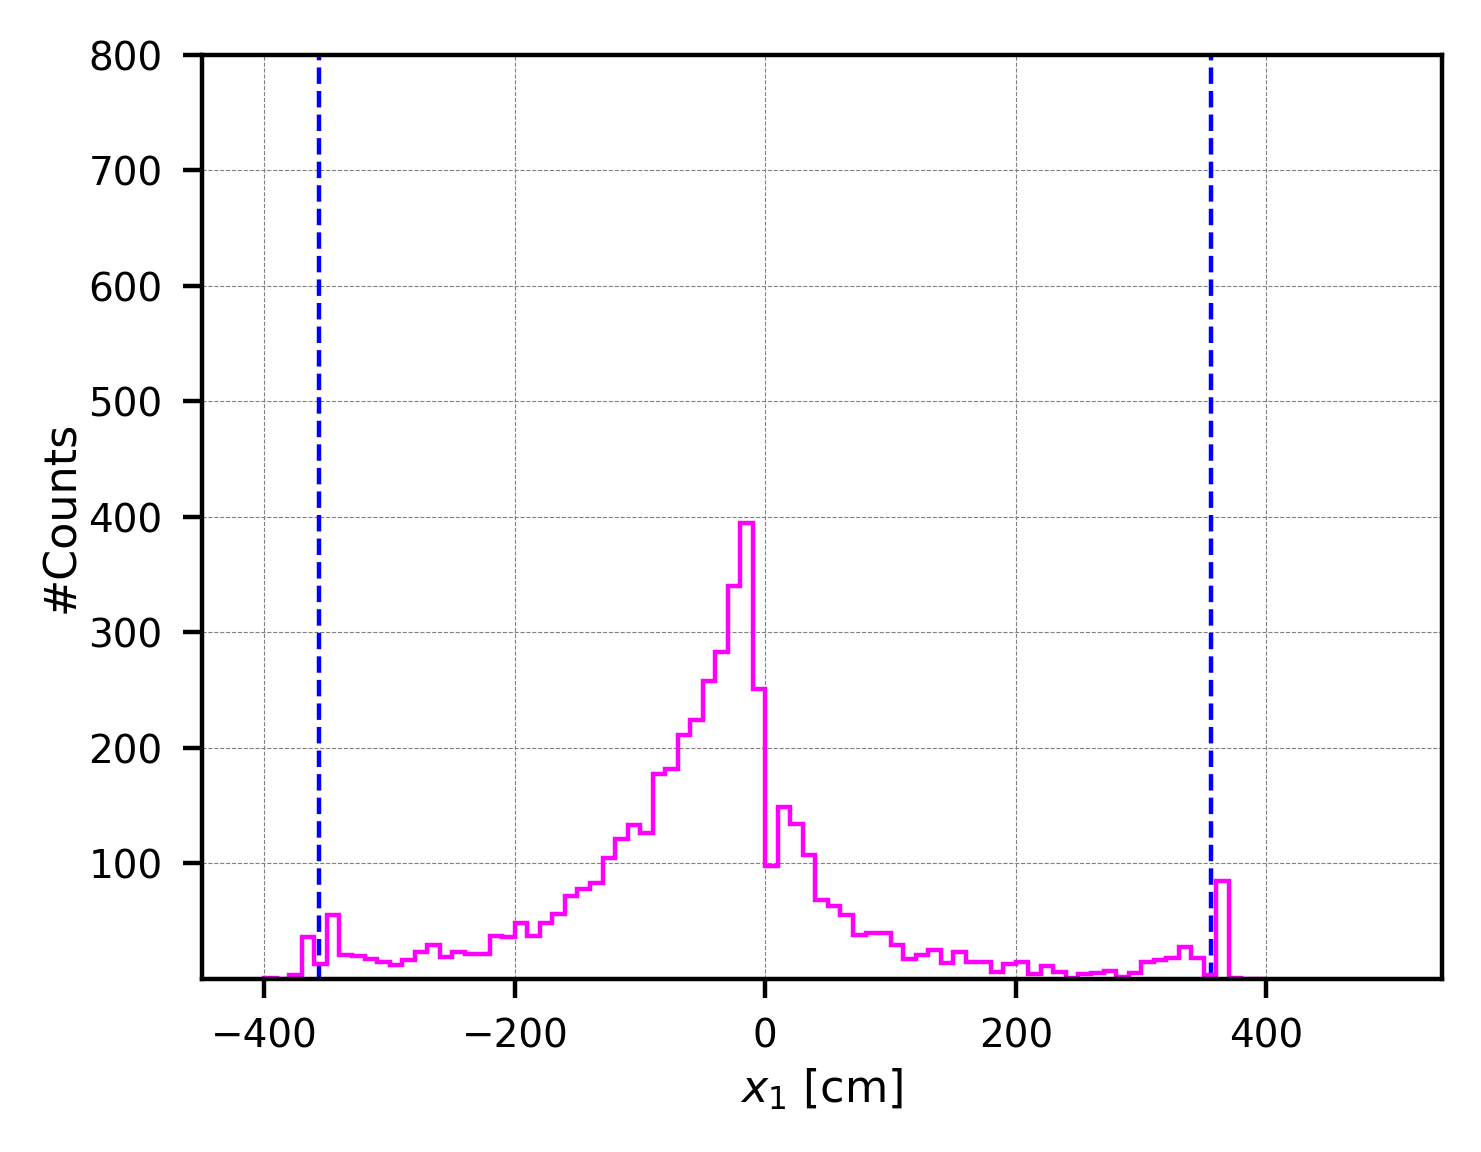

In [20]:
cutX = []
cutY = []
cutZ = []


for i in range(0, len(decayX)):
    X = decayX[i]
    Y = decayY[i]
    Z = decayZ[i]

#    print("Y", Y)
    
    #Default region: 0<y<610, 0<z<465---
    if 25 < Y < 610 and 25 < Z < 440:
        cutX.append(X)
        cutY.append(Y)
        cutZ.append(Z)

print("Size of cutX: ", len(cutX))
print("Size of cutY: ", len(cutY))
print("Size of cutZ: ", len(cutZ))




#Statistics for different distances-----------------------
count10 = 0
count10_50 = 0
count50_100 = 0
count100_200 = 0
count200_300 = 0
count300 = 0

for value in cutX:
    #APA planes are at x=-356 & x=356
    if  value <= -346 or value >= 346:
        count10 += 1
    elif -346 < value <= -306 or 306 <= value < 346:
        count10_50 += 1
    elif -306 < value <= -256 or 256 <= value < 306:
        count50_100 += 1 
    elif -256 < value <= -156 or 156 <= value < 256:
        count100_200 += 1    
    elif -156 < value <= -56 or 56 <= value < 156:
        count200_300 += 1 
    else:
        count300 += 1

# Output the counts
print("Distance to APAs    [0, 10]: ", count10)
print("Distance to APAs   (10, 50]: ", count10_50)
print("Distance to APAs  (50, 100]: ", count50_100)
print("Distance to APAs (100, 200]: ", count100_200)
print("Distance to APAs (200, 300]: ", count200_300)
print("Distance to APAs (300, inf): ", count300)





#Y-Z plane ploting----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(cutZ, cutY, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()    




# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-356, -356], [0, 800], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 800], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(cutX, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(-450, 540)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 800)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## RSL vs Energy and Wavelength:

Based on the data shared by Jose.

<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:65: SyntaxWarning: invalid escape sequence '\g'
<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:65: SyntaxWarning: invalid escape sequence '\g'
/var/folders/c9/547_2pf11mv74b226lzvqwj00000gn/T/ipykernel_7439/1391722096.py:35: SyntaxWarning: invalid escape sequence '\g'
  plt.xlabel('E($\gamma$) [eV]', labelpad=1, fontsize=8)
/var/folders/c9/547_2pf11mv74b226lzvqwj00000gn/T/ipykernel_7439/1391722096.py:65: SyntaxWarning: invalid escape sequence '\g'
  plt.xlabel('Wavelength($\gamma$) [nm]', labelpad=1, fontsize=8)


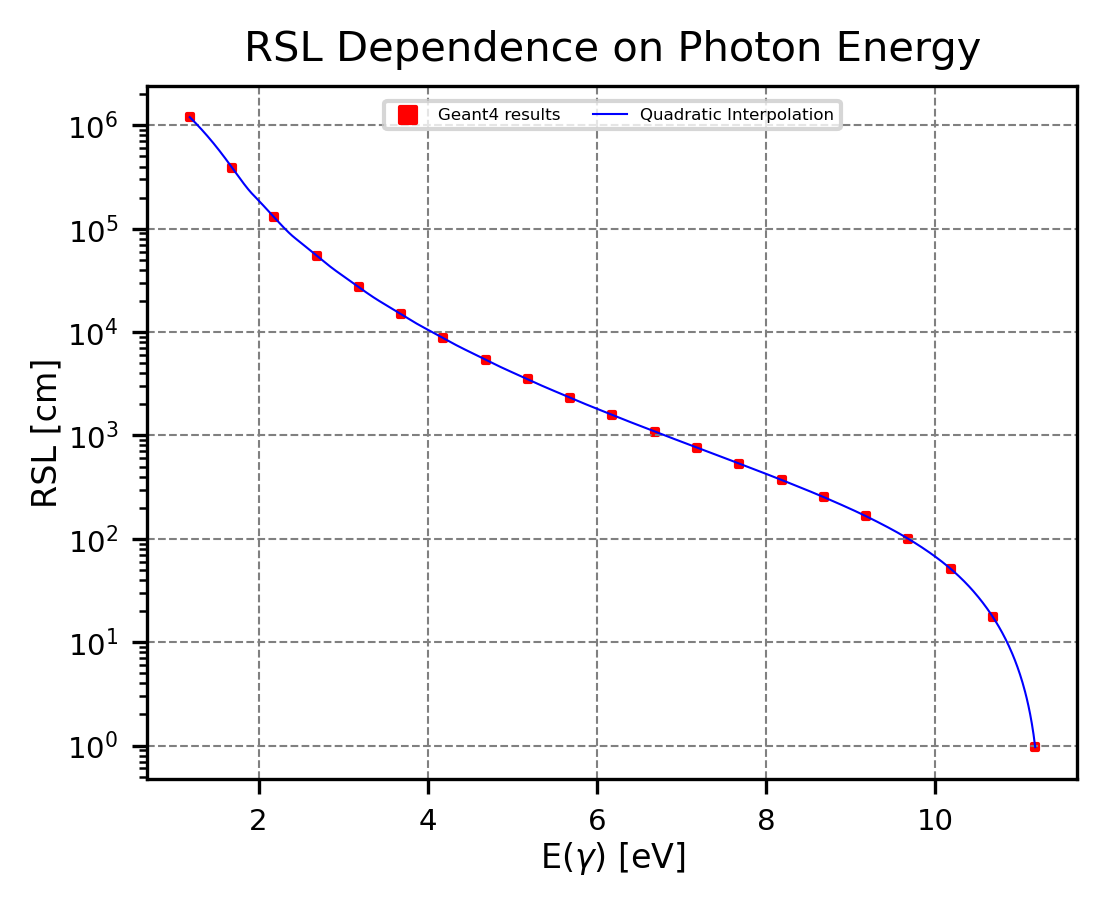

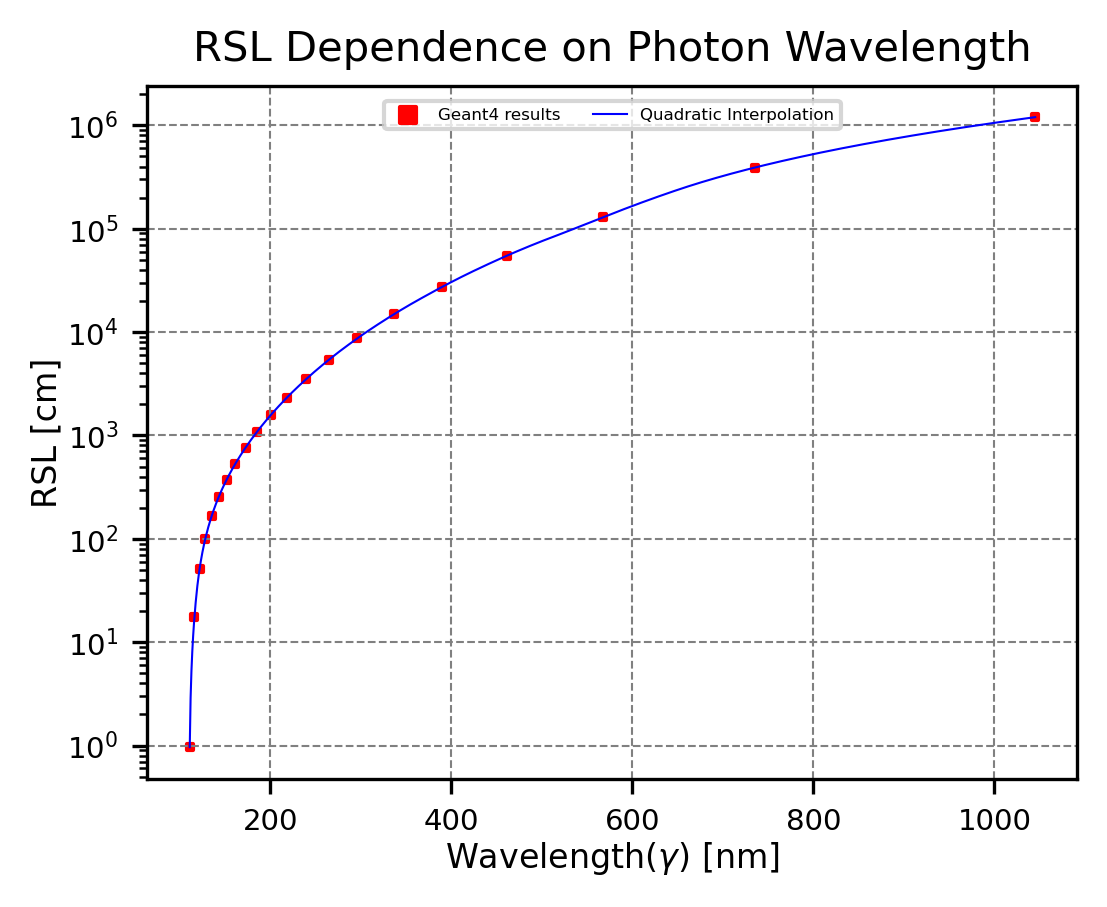

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d


# Sample data---
energy = [1.18626, 1.68626, 2.18626, 2.68626, 3.18626, 3.68626, 4.18626, 4.68626, 5.18626, 5.68626, 
            6.18626, 6.68626, 7.18626, 7.68626, 8.18626, 8.68626, 9.18626, 9.68626, 10.1863, 10.6863, 11.1863]
rsl = [1200800, 390747, 128633, 54969.1, 27191.8, 14853.7, 8716.9, 5397.42, 3481.37, 2316.51,
       1577.63, 1092.02, 763.045, 534.232, 371.335, 252.942, 165.38, 99.9003, 51.2653, 17.495, 0.964341]
#Wavelength---
energy_array = np.array(energy)
wave_array_tmp = np.reciprocal(energy_array)#array---
wave_array = 2*np.pi*197.326980*wave_array_tmp
wave = wave_array.tolist()#list---




#RSL vs Energy Drawing------------------------------
plt.figure(figsize=(4,3),dpi=300)

plt.scatter(energy, rsl, label='Geant4 results', s=1.5, color='red', marker='s')

# Perform quadratic interpolation
quadratic_interp = interp1d(energy, rsl, kind='quadratic')

#Create a smooth line connecting the points using quadratic interpolation---
smooth_line = np.linspace(min(energy), max(energy), 1000)
smooth_line_y = quadratic_interp(smooth_line)
plt.plot(smooth_line, smooth_line_y, label='Quadratic Interpolation', color='blue', linewidth=0.5)


# Add labels and title---
plt.xlabel('E($\gamma$) [eV]', labelpad=1, fontsize=8)
plt.ylabel('RSL [cm]', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.yscale('log')

plt.title("RSL Dependence on Photon Energy", fontsize=10)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.99), fontsize=6, markerscale=3, ncol=2, prop={'size': 4})
plt.grid(color='gray', linestyle='--', linewidth=0.5, zorder=0)
plt.show()






#RSL vs Energy Drawing------------------------------
plt.figure(figsize=(4,3),dpi=300)

plt.scatter(wave, rsl, label='Geant4 results', s=1.5, color='red', marker='s')

# Perform quadratic interpolation
quadratic_interp = interp1d(wave, rsl, kind='quadratic')

#Create a smooth line connecting the points using quadratic interpolation---
smooth_line = np.linspace(min(wave), max(wave), 1000)
smooth_line_y = quadratic_interp(smooth_line)
plt.plot(smooth_line, smooth_line_y, label='Quadratic Interpolation', color='blue', linewidth=0.5)


# Add labels and title---
plt.xlabel('Wavelength($\gamma$) [nm]', labelpad=1, fontsize=8)
plt.ylabel('RSL [cm]', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.yscale('log')

plt.title("RSL Dependence on Photon Wavelength", fontsize=10)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.99), fontsize=6, markerscale=3, ncol=2, prop={'size': 4})
plt.grid(color='gray', linestyle='--', linewidth=0.5, zorder=0)
plt.show()


